# Machine Learning Classification Project
## CSC14005 – Đồ án Phân lớp (Classification)

**Họ và tên:** _[Điền tên]_  **MSSV:** _[Điền MSSV]_  **Lớp:** _[Điền lớp]_

---

### 📌 Bố cục Dataset

| Bài toán | Dataset | Target |
|----------|---------|--------|
| **Nhị phân** (Binary) | Adult Census Income (`adult.csv`) | `income`: <=50K (0) / >50K (1) |
| **Đa lớp** (Multi-class) | **Synthesis từ `sklearn.datasets.make_classification`** | 3 lớp cân bằng |

> **Ghi chú:** Adult.csv là bài toán **nhị phân** thuần tuý (2 lớp). Để so sánh các chiến lược đa lớp (Softmax vs OvR vs OvO), ta dùng **synthesis data** từ `sklearn` thay vì tạo target giả tạo từ dataset gốc.  
> *(Theo hướng dẫn của thầy: "Em có thể chọn thêm hoặc sử dụng một ví dụ synthesis nào đó từ sklearn để so sánh.")*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from scipy.stats import norm

import sys, os
sys.path.insert(0, '.')
from utils import *

custom_cm = confusion_matrix   # alias: confusion_matrix từ utils

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline
np.random.seed(42)
print("✓ Imported successfully!")


✓ Imported successfully!


In [2]:
DATA_PATH = '../../data/adult.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K


---
## 1. EDA – Dataset 1: Adult Census Income

**Mục tiêu nhị phân:** `income` → 0 (<=50K) hoặc 1 (>50K)

### 1.1 Mô tả dữ liệu

**Nguồn:** UCI Adult Census Income Dataset – 32,561 mẫu, 14 đặc trưng + 1 nhãn mục tiêu.

| Biến | Kiểu | Ý nghĩa |
|------|------|---------|
| `age` | Numerical | Tuổi người lao động |
| `workclass` | Categorical | Loại hình làm việc (Private, Self-emp, Gov, ...) |
| `fnlwgt` | Numerical | Final weight – trọng số thống kê (không dùng trực tiếp) |
| `education` | Categorical | Cấp học (Bachelors, HS-grad, Masters, ...) |
| `education.num` | Numerical | Số năm học tương ứng cấp học (1–16) |
| `marital.status` | Categorical | Tình trạng hôn nhân |
| `occupation` | Categorical | Nghề nghiệp |
| `relationship` | Categorical | Vai trò trong gia đình (Husband, Wife, ...) |
| `race` | Categorical | Chủng tộc |
| `sex` | Categorical | Giới tính |
| `capital.gain` | Numerical | Lãi từ đầu tư vốn |
| `capital.loss` | Numerical | Lỗ từ đầu tư vốn |
| `hours.per.week` | Numerical | Số giờ làm việc mỗi tuần |
| `native.country` | Categorical | Quê quán / quốc tịch |
| `income` (**target**) | Binary | Thu nhập: <=50K → **0** / >50K → **1** |


In [3]:
# ── 1.2 Basic info & missing values ─────────────────────────────────────────
num_cols = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']

y_raw = df_raw['income'].str.strip().map({'<=50K':0,'>50K':1})
print(f"Shape: {df_raw.shape}  |  Samples: {len(df_raw):,}  |  Features: {df_raw.shape[1]-1}")
print(f"\nKiểu dữ liệu:")
print(df_raw.dtypes.to_string())
print(f"\nMissing values ('?'):")
has_miss = False
for col in df_raw.columns:
    n = (df_raw[col].astype(str).str.strip()=='?').sum()
    if n:
        print(f"  {col}: {n:,} ({n/len(df_raw)*100:.1f}%)")
        has_miss = True
if not has_miss:
    print("  None")
print(f"\nClass distribution:")
print(y_raw.value_counts().rename({0:'<=50K (0)',1:'>50K (1)'}).to_string())

# ── Thống kê mô tả (mean, std, min, max, tứ phân vị) ─────────────────────────
print("\n" + "="*70)
print("=== Thống kê mô tả – Numerical Features ===")
desc = df_raw[num_cols].describe().round(2)
print(desc.to_string())


Shape: (32561, 15)  |  Samples: 32,561  |  Features: 14

Kiểu dữ liệu:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object

Missing values ('?'):
  workclass: 1,836 (5.6%)
  occupation: 1,843 (5.7%)
  native.country: 583 (1.8%)

Class distribution:
income
<=50K (0)    24720
>50K (1)      7841

=== Thống kê mô tả – Numerical Features ===
            age      fnlwgt  education.num  capital.gain  capital.loss  hours.per.week
count  32561.00    32561.00       32561.00      32561.00      32561.00        32561.00
mean      38.58   189778.37          10.08       1077.65         87.30           40.44
std       13.64   105549.98           2.57       7385.29        402.96       

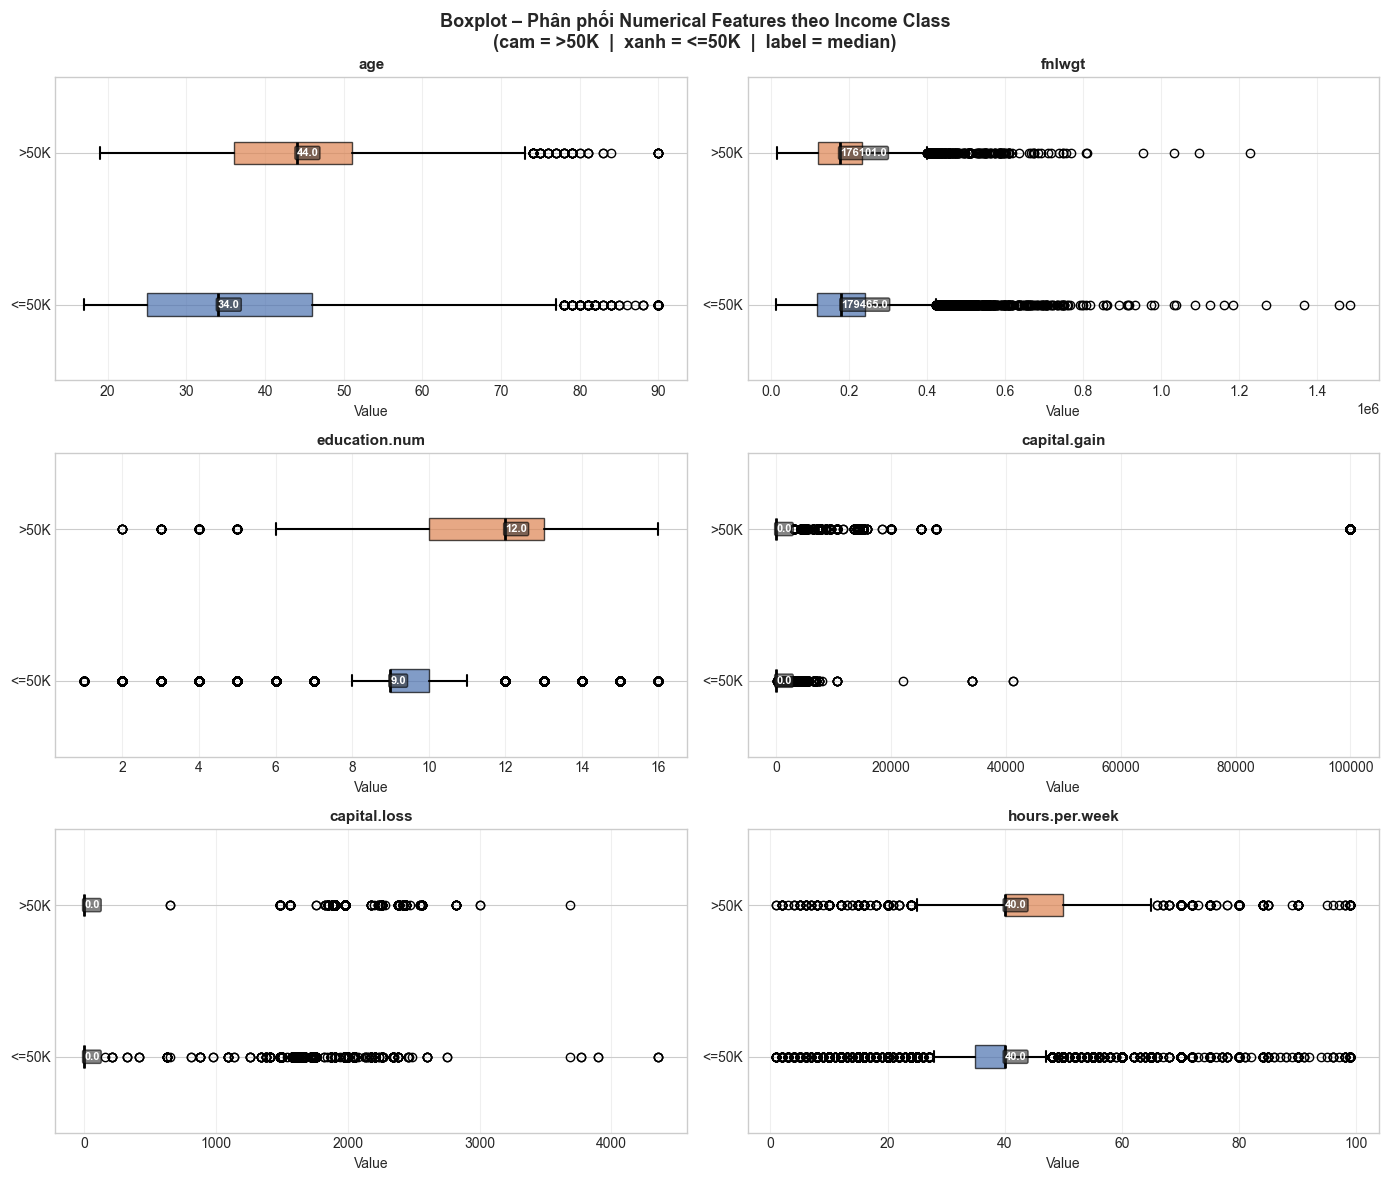

Nhận xét:
  age               : median <=50K=34.0, >50K=44.0  (Δ=+29.4%)
  fnlwgt            : median <=50K=179465.0, >50K=176101.0  (Δ=-1.9%)
  education.num     : median <=50K=9.0, >50K=12.0  (Δ=+33.3%)
  capital.gain      : median <=50K=0.0, >50K=0.0  (Δ=+0.0%)
  capital.loss      : median <=50K=0.0, >50K=0.0  (Δ=+0.0%)
  hours.per.week    : median <=50K=40.0, >50K=40.0  (Δ=+0.0%)


In [4]:
# ── 1.3 Boxplot theo class ────────────────────────────────────────────────────
plot_boxplots_by_class(df_raw, num_cols, y_raw)


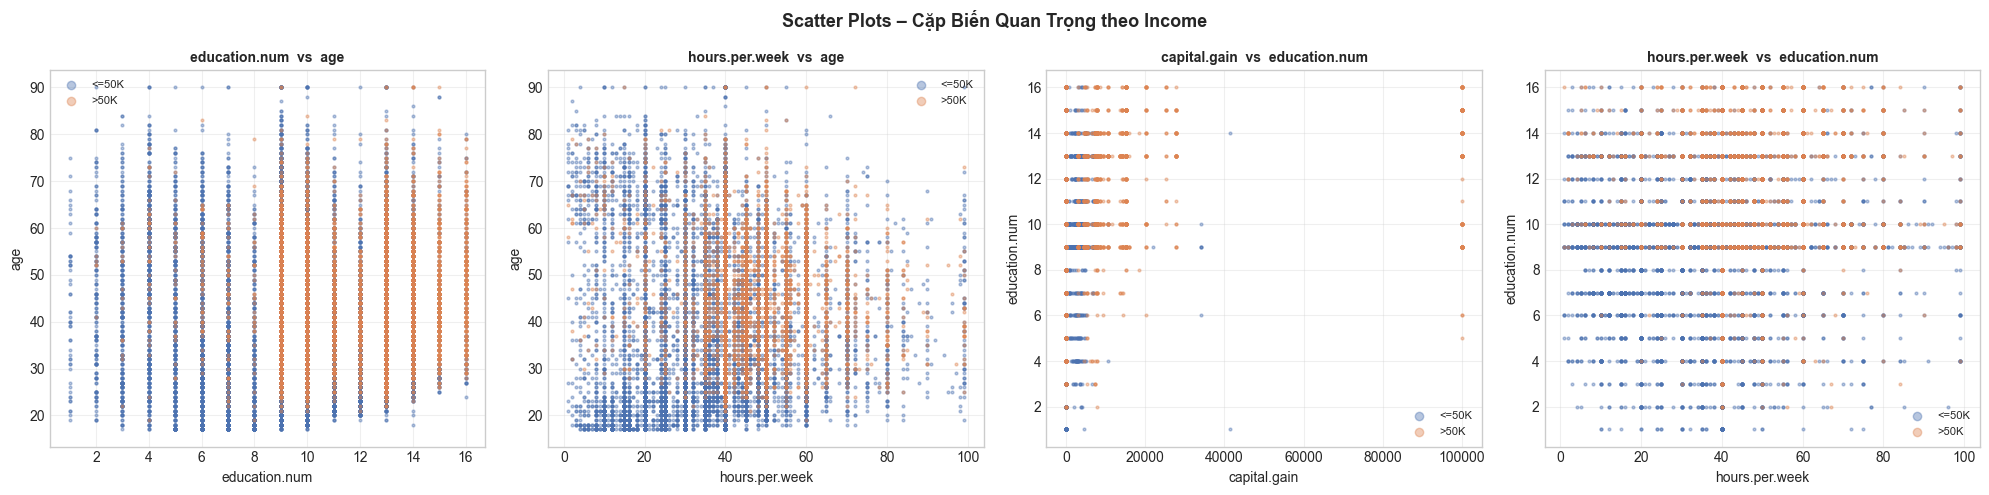

Tương quan Pearson với target (income):
  education.num       : +0.3352  ██████████
  age                 : +0.2340  ███████
  hours.per.week      : +0.2297  ██████
  capital.gain        : +0.2233  ██████
  capital.loss        : +0.1505  ████
  fnlwgt              : -0.0095  


In [5]:
# ── 1.4 Scatter Plots – Cặp biến quan trọng ──────────────────────────────────
pairs = [
    ('education.num', 'age'),
    ('hours.per.week', 'age'),
    ('capital.gain',  'education.num'),
    ('hours.per.week', 'education.num'),
]
plot_scatter_pairs(df_raw, y_raw, pairs)


Feature                 IQR #   IQR %    Z>3 #   Z>3 %    Skewness
────────────────────────────────────────────────────────────────────
  age                     143    0.4%      121    0.4%       +0.56
  fnlwgt                  992    3.0%      347    1.1%       +1.45
  education.num         1,198    3.7%      219    0.7%       -0.31
  capital.gain          2,712    8.3%      215    0.7%      +11.95
  capital.loss          1,519    4.7%    1,470    4.5%       +4.59
  hours.per.week        9,008   27.7%      440    1.4%       +0.23
────────────────────────────────────────────────────────────────────
* IQR rule: < Q1−1.5·IQR  hoặc  > Q3+1.5·IQR
* Z-score:  |z| > 3  (≈ 0.3% dưới normal distribution)


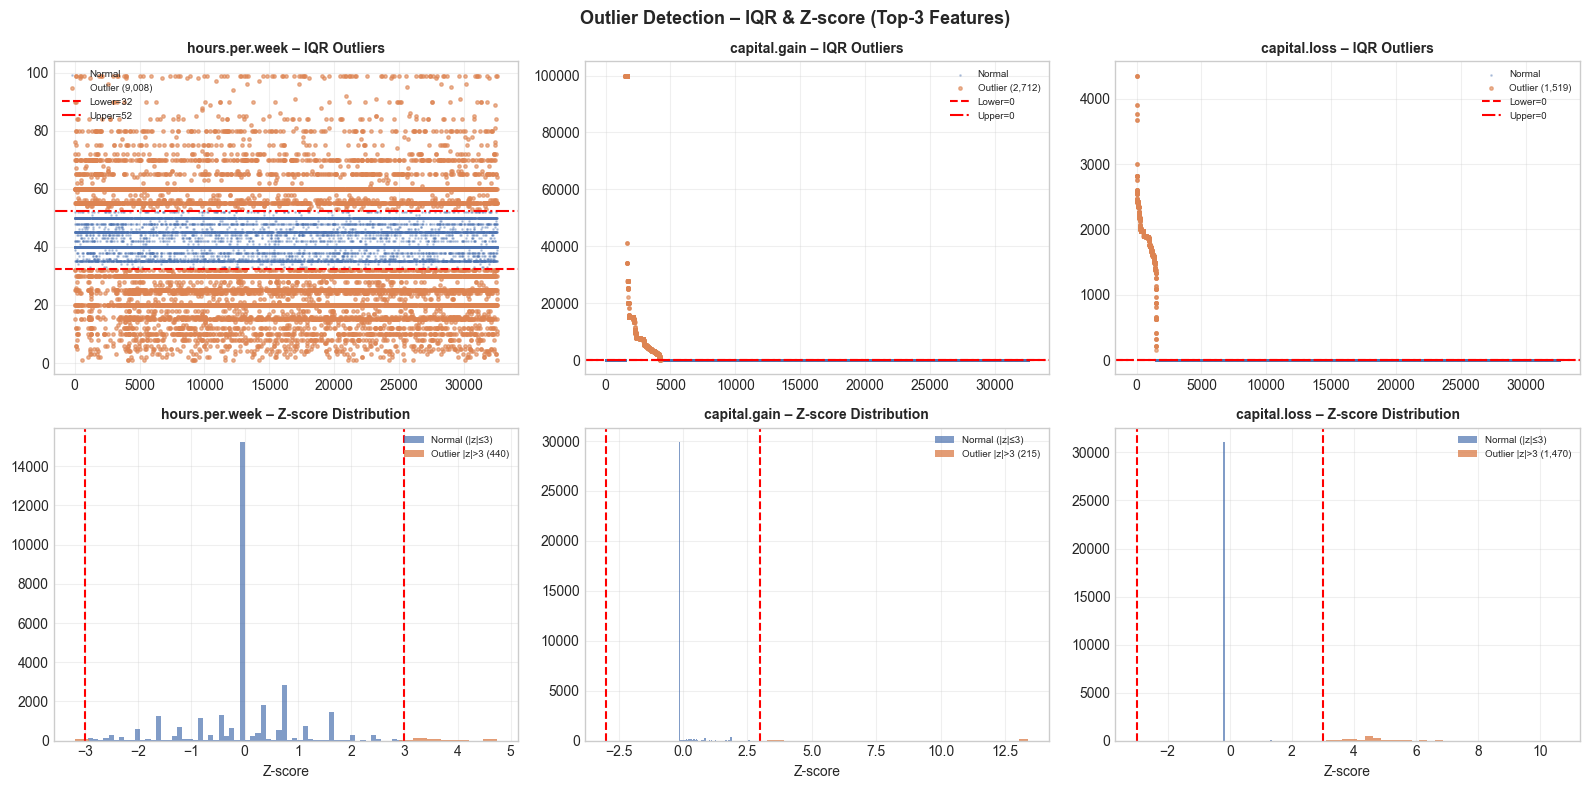

In [6]:
# ── 1.5 Phát hiện Ngoại lai ───────────────────────────────────────────────────
plot_outlier_detection(df_raw, num_cols)


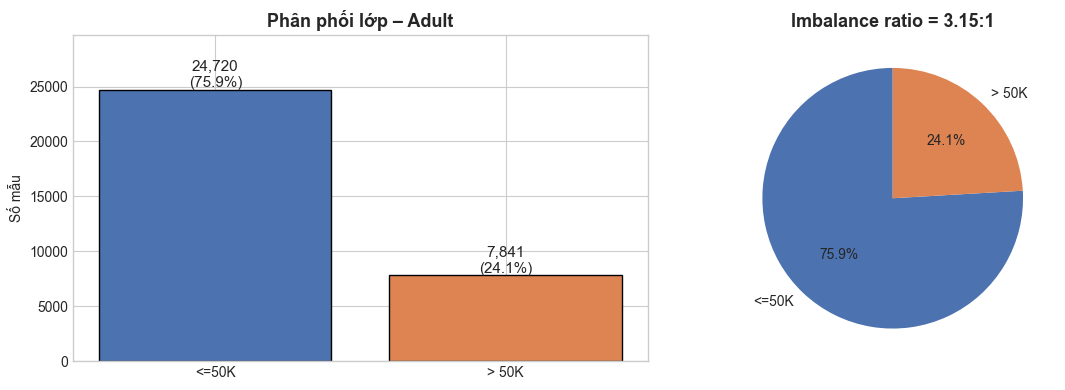

In [7]:
# ── 1.1 Phân phối lớp (Class Distribution) ───────────────────────────────────
plot_class_distribution(y_raw)


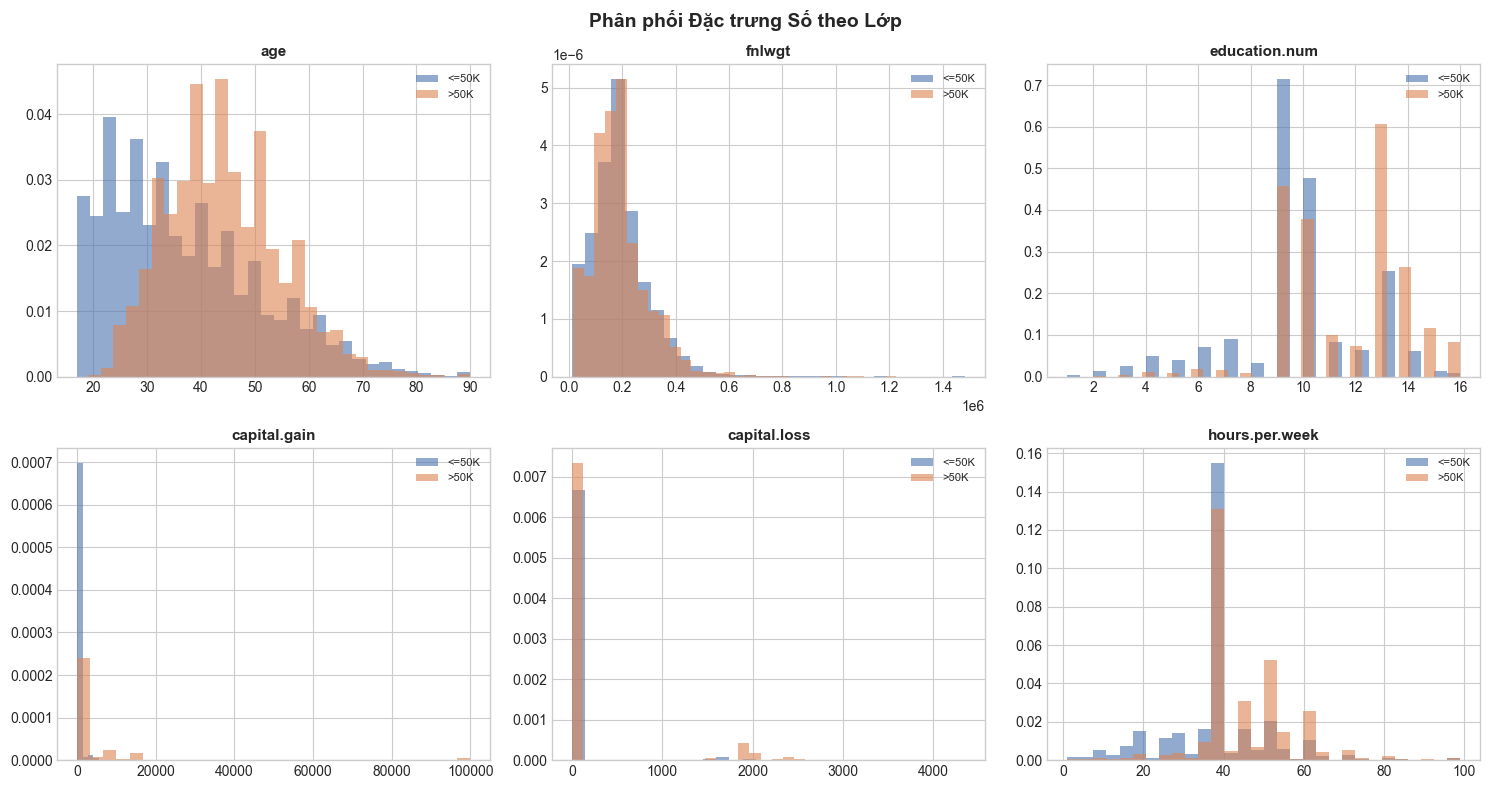

In [8]:
# ── 1.2 Histogram theo class ──────────────────────────────────────────────────
plot_histograms_by_class(df_raw, num_cols, y_raw)


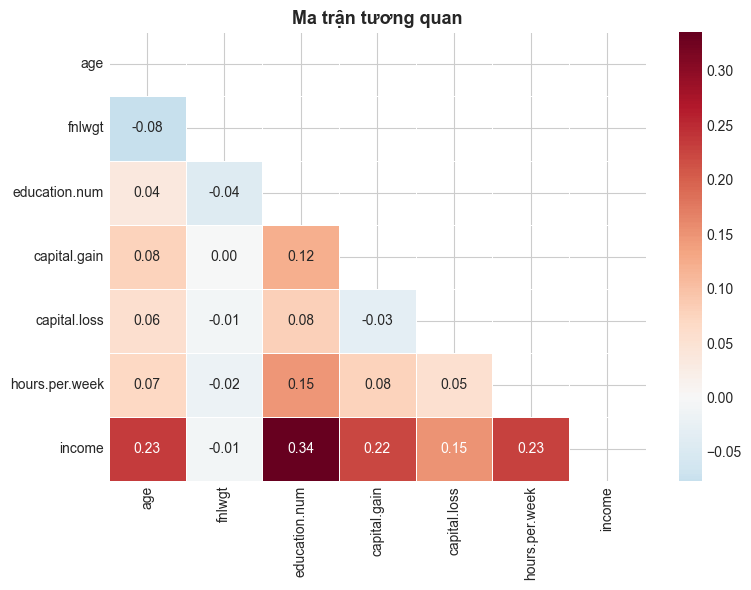


Tương quan với income:
education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
capital.loss      0.150526
fnlwgt           -0.009463


In [9]:
# Correlation heatmap
num_data = df_raw[num_cols].copy(); num_data['income'] = y_raw
corr = num_data.corr()
fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=np.triu(np.ones_like(corr,dtype=bool)), ax=ax, linewidths=0.5)
ax.set_title('Ma trận tương quan', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("\nTương quan với income:")
print(corr['income'].drop('income').sort_values(ascending=False).to_string())


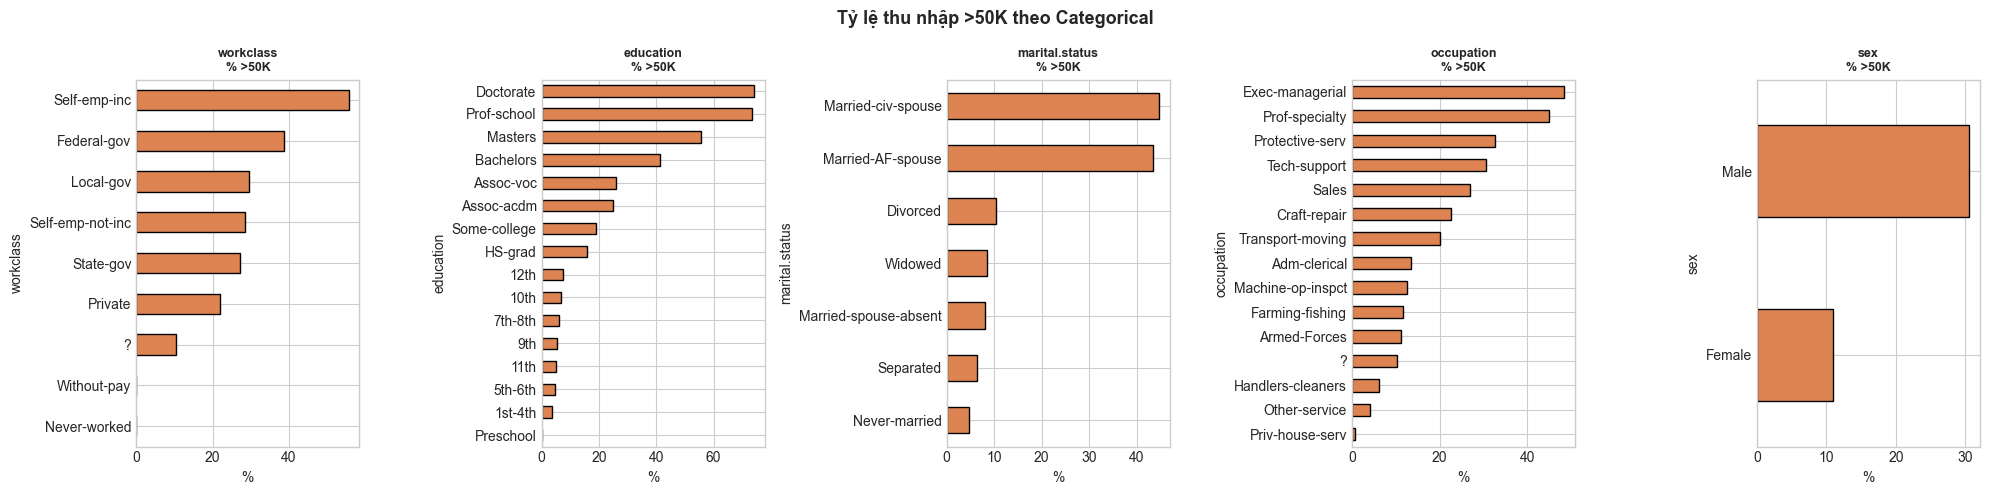

In [10]:
# Categorical features
cat_cols = ['workclass','education','marital.status','occupation','sex']
fig,axes = plt.subplots(1,5,figsize=(20,5))
for ax,col in zip(axes,cat_cols):
    ct = pd.crosstab(df_raw[col].str.strip(), y_raw, normalize='index')*100
    ct.columns=['<=50K','>50K']
    ct['>50K'].sort_values().plot(kind='barh', ax=ax, color='#DD8452', edgecolor='k')
    ax.set_title(f'{col}\n% >50K', fontsize=9, fontweight='bold')
    ax.set_xlabel('%')
plt.suptitle('Tỷ lệ thu nhập >50K theo Categorical', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 2. EDA – Dataset cho Bài toán Đa lớp (Synthesis từ Sklearn)

### ❓ Tại sao không dùng adult.csv cho đa lớp?

- **Bài toán nhị phân (binary classification):** Target chỉ có **2 giá trị** (0/1). Adult.csv có target `income` = <=50K hoặc >50K → đây là bài toán nhị phân.
- **Bài toán đa lớp (multi-class classification):** Target có **≥ 3 giá trị**. Vì adult là binary, **không cần** (và không nên) tạo thêm target giả tạo.
- **Giải pháp:** Dùng `sklearn.datasets.make_classification` để tạo **synthesis data** 3 lớp → minh hoạ và so sánh các chiến lược đa lớp một cách rõ ràng.

### 📊 Hai bộ synthesis được tạo:
1. **10D (10 features):** Dùng để **huấn luyện và đánh giá** metrics (Accuracy, F1, ...)  
2. **2D (2 features):** Dùng để **vẽ decision boundary** trực quan


=== Synthesis Multi-class Data ===
10D (training) : (1500, 10)  | Classes: [500 499 501]
2D  (viz)      : (600, 2) | Classes: [202 198 200]


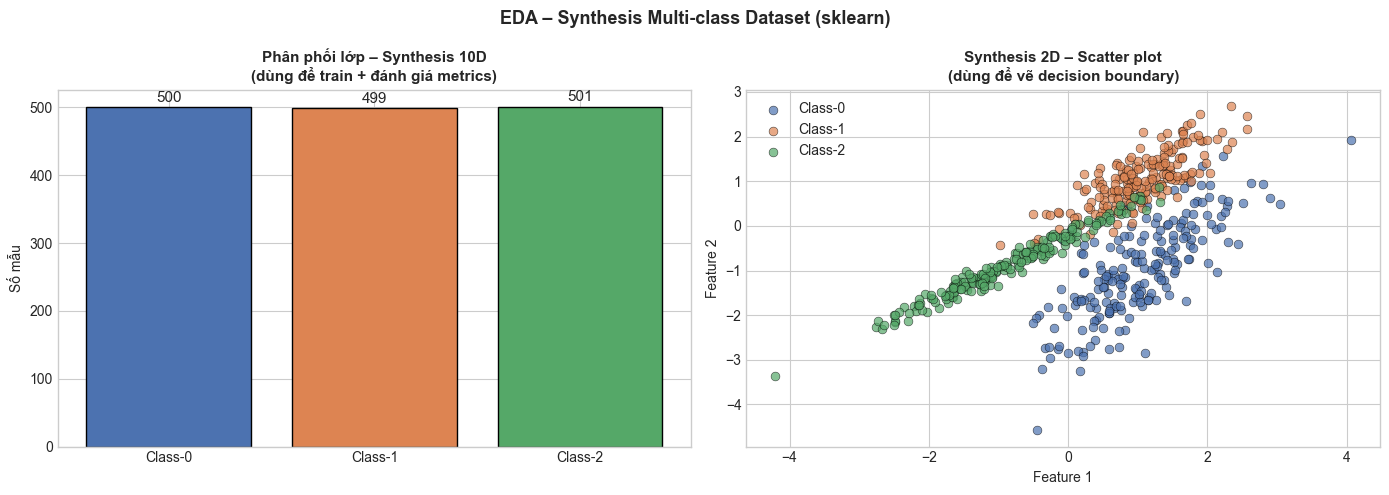

In [11]:
from sklearn.datasets import make_classification

# --- Synthesis 10D: training & evaluation ---
X_syn, y_syn = make_classification(
    n_samples=1500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

# --- Synthesis 2D: decision boundary visualization ---
X_syn2d, y_syn2d = make_classification(
    n_samples=600, n_features=2, n_redundant=0, n_informative=2,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

class_names = ['Class-0', 'Class-1', 'Class-2']
syn_colors  = ['#4C72B0', '#DD8452', '#55A868']

print("=== Synthesis Multi-class Data ===")
print(f"10D (training) : {X_syn.shape}  | Classes: {np.bincount(y_syn)}")
print(f"2D  (viz)      : {X_syn2d.shape} | Classes: {np.bincount(y_syn2d)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: class balance
axes[0].bar(class_names, np.bincount(y_syn), color=syn_colors, edgecolor='k')
for i, v in enumerate(np.bincount(y_syn)):
    axes[0].text(i, v + 8, str(v), ha='center', fontsize=11)
axes[0].set_title('Phân phối lớp – Synthesis 10D\n(dùng để train + đánh giá metrics)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Số mẫu')

# 2D scatter
for cls, color, name in zip(range(3), syn_colors, class_names):
    mask = y_syn2d == cls
    axes[1].scatter(X_syn2d[mask, 0], X_syn2d[mask, 1],
                    c=color, label=name, s=40, edgecolors='k', alpha=0.7, linewidths=0.4)
axes[1].set_title('Synthesis 2D – Scatter plot\n(dùng để vẽ decision boundary)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.suptitle('EDA – Synthesis Multi-class Dataset (sklearn)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 3. Tiền xử lý (Preprocessing)

### 3.1 Adult Binary

**Xử lý missing values:**  
Thay `?` bằng **mode** của từng cột categorical (`workclass`, `occupation`, `native.country`) – phương pháp đơn giản, phù hợp với dữ liệu danh mục có phân phối lệch nhẹ.

**Feature Engineering:**
- `capital_net = capital.gain - capital.loss` – biểu diễn lợi nhuận ròng từ đầu tư.
- `is_married` – biến nhị phân từ `marital.status` (Married-civ / Married-AF = 1, còn lại = 0).

**Encoding Categorical Features:** `LabelEncoder` – gán số nguyên cho mỗi category.

- **Tại sao không dùng OneHotEncoder?**  
  Các features categorical (`workclass`, `occupation`, `relationship`, `sex`, `race`) có tổng cộng ~35 unique values. OneHotEncoder sẽ tạo thêm ~30 cột binary, làm feature matrix tăng đột biến và thêm nhiễu (curse of dimensionality).  
  LabelEncoder giữ feature space compact (12D thay vì ~40D), đủ cho các mô hình linear. `StandardScaler` áp dụng sau giúp giảm thiểu ảnh hưởng của thứ tự số giả.  
- **Lưu ý giới hạn:** LabelEncoder ngầm tạo thứ tự thứ bậc giả (ví dụ: `Private=0 < Gov=1`). Với các mô hình linear đơn giản trong đồ án này, đây là trade-off chấp nhận được.

**Chuẩn hóa:** `StandardScaler` – z-score normalization: $x' = \dfrac{x - \mu}{\sigma}$

- **Lý do chọn StandardScaler thay MinMaxScaler:**  
  Adult có các features với phân phối lệch mạnh và nhiều outliers (đặc biệt `capital.gain`, `fnlwgt`). MinMaxScaler nhạy cảm với outliers (do dùng min/max); StandardScaler dùng mean/std nên **robust hơn**.  
- **Quy tắc data leakage:** Fit ONLY trên **train** set, rồi transform **val & test** (tránh thông tin từ val/test ảnh hưởng scale).

**Chia dữ liệu:** **Train / Validation / Test = 70% / 10% / 20%** (stratified theo `income`)
- **Test set (20%):** Đánh giá cuối cùng, chỉ dùng 1 lần.
- **Validation set (10%):** Tuning hyperparameter / model selection.
- **Train set (70%):** Huấn luyện model.

In [12]:
# Clean
df = df_raw.copy()
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()
for col in ['workclass','occupation','native.country']:
    mode_v = df[df[col]!='?'][col].mode()[0]
    df[col] = df[col].replace('?', mode_v)

y_binary = (df['income']=='>50K').astype(int).values

# Feature engineering
df['capital_net'] = df['capital.gain'] - df['capital.loss']
df['is_married'] = df['marital.status'].isin(['Married-civ-spouse','Married-AF-spouse']).astype(int)

num_features = ['age','education.num','hours.per.week','capital_net','capital.gain','capital.loss','fnlwgt']
cat_features = ['workclass','occupation','relationship','sex','race']

le = LabelEncoder()
cat_enc = pd.DataFrame({col: le.fit_transform(df[col]) for col in cat_features})
X_all = np.hstack([df[num_features].values, cat_enc.values]).astype(float)
feature_names = num_features + cat_features
print(f"X shape: {X_all.shape}, y: {y_binary.shape}")


X shape: (32561, 12), y: (32561,)


In [13]:
# Train / Val / Test split – 70 / 10 / 20  (stratified)
X_trainval, X_te, y_trainval, y_te = train_test_split(
    X_all, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)
# 0.125 × 0.80 = 0.10 of total → effectively 70/10/20

scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)    # fit ONLY on train
X_val_sc = scaler.transform(X_val)       # transform val
X_te_sc  = scaler.transform(X_te)        # transform test

# Fisher top-2 proxy for visualization
feat_var = np.var(X_tr_sc, axis=0)
top2_idx = np.argsort(feat_var)[::-1][:2]
X_tr_2d  = X_tr_sc[:, top2_idx]
X_te_2d  = X_te_sc[:, top2_idx]
feat_2d  = [feature_names[i] for i in top2_idx]

n_total = len(X_all)
print(f"Total : {n_total:,}")
print(f"Train : {len(X_tr):,}  ({len(X_tr)/n_total*100:.1f}%)"
      f" | class 0={( y_tr==0).sum():,}  class 1={(y_tr==1).sum():,}")
print(f"Val   : {len(X_val):,}   ({len(X_val)/n_total*100:.1f}%)")
print(f"Test  : {len(X_te):,}  ({len(X_te)/n_total*100:.1f}%)")
print(f"Feature matrix: {X_tr_sc.shape[1]}D")
print(f"2D viz features: {feat_2d}")


Total : 32,561
Train : 22,792  (70.0%) | class 0=17,303  class 1=5,489
Val   : 3,256   (10.0%)
Test  : 6,513  (20.0%)
Feature matrix: 12D
2D viz features: ['hours.per.week', 'relationship']


### 3.2 Preprocessing – Synthesis Multi-class Data

Tách train/test và chuẩn hoá cho **cả 2 bộ** synthesis (10D và 2D).


In [14]:
# Synthesis 10D – dùng để train và đánh giá
X_syn_tr, X_syn_te, y_syn_tr, y_syn_te = train_test_split(
    X_syn, y_syn, test_size=0.2, random_state=42, stratify=y_syn
)
scaler_syn = StandardScaler()
X_syn_tr_sc = scaler_syn.fit_transform(X_syn_tr)
X_syn_te_sc  = scaler_syn.transform(X_syn_te)

# Synthesis 2D – dùng để vẽ decision boundary
X_syn2d_tr, X_syn2d_te, y_syn2d_tr, y_syn2d_te = train_test_split(
    X_syn2d, y_syn2d, test_size=0.2, random_state=42, stratify=y_syn2d
)
scaler_syn2d = StandardScaler()
X_syn2d_tr_sc = scaler_syn2d.fit_transform(X_syn2d_tr)
X_syn2d_te_sc  = scaler_syn2d.transform(X_syn2d_te)

print(f"10D → Train: {X_syn_tr_sc.shape} | Test: {X_syn_te_sc.shape}")
print(f"2D  → Train: {X_syn2d_tr_sc.shape} | Test: {X_syn2d_te_sc.shape}")
print(f"Class balance (10D train): {np.bincount(y_syn_tr)}")


10D → Train: (1200, 10) | Test: (300, 10)
2D  → Train: (480, 2) | Test: (120, 2)
Class balance (10D train): [400 399 401]


---
## 4. Logistic Regression

### 4.1 Lý thuyết – Binary Classification (Sigmoid + Gradient Descent)

---

#### Mô hình (Model)

$$h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1+e^{-\theta^T x}}$$

**Ký hiệu:**
- $x \in \mathbb{R}^{D+1}$ — vector đặc trưng đã augment (thêm $x_0=1$ cho bias)
- $\theta \in \mathbb{R}^{D+1}$ — vector tham số: $[\theta_0, \theta_1, \ldots, \theta_D]$, trong đó $\theta_0$ là bias
- $\theta^T x = \theta_0 + \theta_1 x_1 + \cdots + \theta_D x_D$ — **linear predictor** (tổ hợp tuyến tính)
- $\sigma(z) = \frac{1}{1+e^{-z}}$ — **hàm sigmoid**, cho ra $h \in (0,1)$
- $h_\theta(x) = P(y=1 \mid x;\theta)$ — xác suất dự đoán **mẫu thuộc lớp 1**

> **Tại sao sigmoid?** Logistic regression là **discriminative model** → học trực tiếp $P(y|x)$. Sigmoid là hàm "squashing" duy nhất thỏa mãn: (1) cho ra giá trị trong $(0,1)$, (2) đạo hàm đơn giản $\sigma'(z)=\sigma(z)(1-\sigma(z))$, (3) tương đương với mô hình xác suất từ họ exponential.

---

#### Hàm mất mát – Cross-Entropy Loss (từ MLE)

Từ **Maximum Likelihood Estimation** với phân phối Bernoulli $P(y|x) = h^y(1-h)^{1-y}$, log-likelihood:

$$\ell(\theta) = \sum_{i=1}^m \left[y^{(i)}\log h^{(i)} + (1-y^{(i)})\log(1-h^{(i)})\right]$$

Tối đa hóa $\ell$ ↔ tối thiểu hóa **Cross-Entropy Loss**:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^m\left[y^{(i)}\log h^{(i)} + (1-y^{(i)})\log(1-h^{(i)})\right]$$

**Ký hiệu:**
- $m$ — số mẫu training
- $y^{(i)} \in \{0,1\}$ — nhãn thực tế của mẫu $i$
- $h^{(i)} = \sigma(\theta^T x^{(i)})$ — xác suất dự đoán của mẫu $i$
- Số hạng thứ nhất $y\log h$: chỉ tính khi $y=1$ (đóng góp loss khi dự đoán sai lớp 1)
- Số hạng thứ hai $(1-y)\log(1-h)$: chỉ tính khi $y=0$ (đóng góp loss khi dự đoán sai lớp 0)

> **Tại sao không dùng MSE?** Với output là xác suất, MSE tạo ra hàm loss **non-convex** → tồn tại local minima. Cross-entropy loss là **convex** với logistic regression → luôn hội tụ về global minimum.

---

#### Gradient và Cập nhật tham số (Gradient Descent)

**Gradient** của $J$ theo $\theta$:

$$\nabla_\theta J = \frac{1}{m}X^T(h-y)$$

**Dạng khai triển** cho tham số $\theta_j$:

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^m \left(h^{(i)} - y^{(i)}\right)x_j^{(i)}$$

**Ký hiệu ma trận:**
- $X \in \mathbb{R}^{m \times (D+1)}$ — ma trận feature (mỗi hàng là $x^{(i)T}$)
- $h \in \mathbb{R}^m$ — vector xác suất dự đoán: $h_i = \sigma(\theta^T x^{(i)})$
- $y \in \mathbb{R}^m$ — vector nhãn thực tế
- $(h - y)$ — **residuals**: sai số dự đoán, range $\in (-1, 1)$

**Cập nhật tham số (Gradient Descent):**

$$\theta^{(t+1)} := \theta^{(t)} - \alpha \cdot \nabla_\theta J$$

**Ký hiệu:**
- $\alpha > 0$ — **learning rate** (tốc độ học): kiểm soát độ lớn bước nhảy
  - $\alpha$ quá lớn → overshoot, không hội tụ
  - $\alpha$ quá nhỏ → hội tụ chậm
- $t$ — chỉ số vòng lặp

> **Trực giác:** Gradient chỉ hướng tăng nhanh nhất của $J$ → bước ngược hướng gradient sẽ giảm loss nhanh nhất.

In [15]:
lr_gd = LogisticRegressionGD(learning_rate=0.1, n_iterations=300)
lr_gd.fit(X_tr_sc, y_tr)
y_pred_gd = lr_gd.predict(X_te_sc)
y_proba_gd = lr_gd.predict_proba(X_te_sc)
m_gd = classification_metrics(y_te, y_pred_gd, average='binary')
print("=== LR – Gradient Descent ===")
for k,v in m_gd.items(): print(f"  {k}: {v:.4f}")
print(f"  Train time: {lr_gd.training_time:.3f}s | Iterations: {len(lr_gd.losses)}")


=== LR – Gradient Descent ===
  precision: 0.7287
  recall: 0.4247
  f1_score: 0.5367
  accuracy: 0.8234
  Train time: 0.495s | Iterations: 300


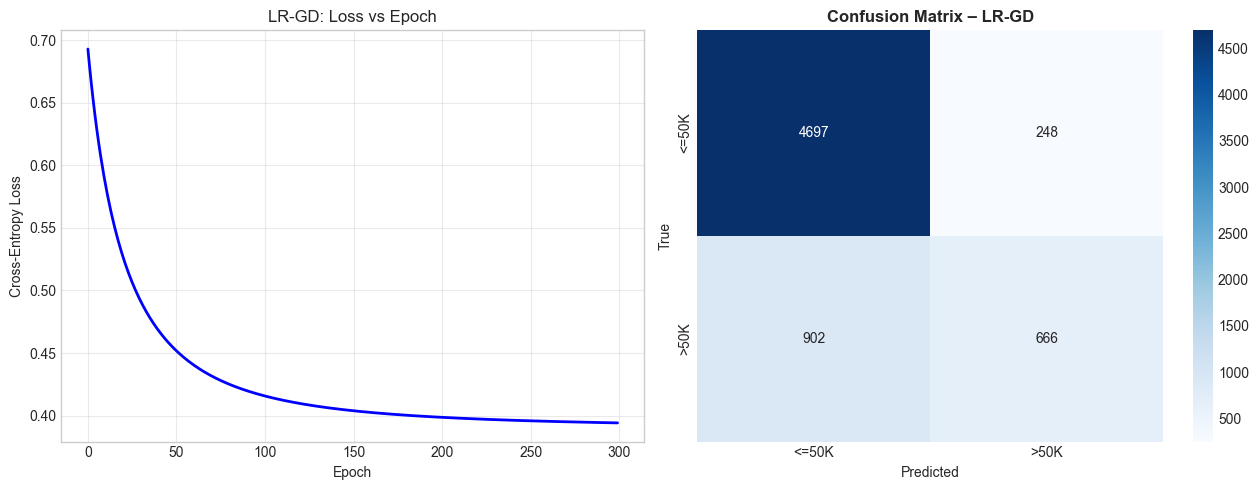

In [ ]:
plot_loss_and_cm(lr_gd.losses, y_te, y_pred_gd,
                 n_classes=2, class_labels=['<=50K','>50K'], title='LR-GD')

### 4.2 Lý thuyết – Newton-Raphson / IRLS

---

#### Ý tưởng cốt lõi

Gradient Descent chỉ dùng **đạo hàm bậc 1** (gradient) để cập nhật tham số → hội tụ chậm. **Newton-Raphson** dùng thêm **đạo hàm bậc 2** (Hessian) để ước lượng **độ cong** (curvature) của hàm mất mát, từ đó bước nhảy thích nghi hơn.

---

#### Công thức cập nhật Newton

$$\theta^{(t+1)} = \theta^{(t)} - H^{-1}\nabla_\theta J$$

**Ký hiệu:**
- $\theta \in \mathbb{R}^{D+1}$ — vector tham số (trọng số + bias), $(D+1)$ vì đã augment bias vào $x$
- $t$ — chỉ số vòng lặp hiện tại
- $\nabla_\theta J \in \mathbb{R}^{D+1}$ — **gradient** của hàm mất mát: $\nabla J = \frac{1}{m}X^T(h - y)$
- $H \in \mathbb{R}^{(D+1)\times(D+1)}$ — **Hessian matrix** (ma trận đạo hàm bậc 2)
- $H^{-1}$ — **nghịch đảo Hessian**, đóng vai trò như một "learning rate thích nghi" theo từng chiều

---

#### Hessian của Cross-Entropy Loss

$$H = \frac{1}{m}X^T D X$$

**Ký hiệu:**
- $m$ — số mẫu training
- $X \in \mathbb{R}^{m \times (D+1)}$ — ma trận feature (đã augment cột bias)
- $D \in \mathbb{R}^{m \times m}$ — **ma trận đường chéo** (diagonal matrix): $D = \mathrm{diag}(h_1(1-h_1),\; h_2(1-h_2),\; \ldots,\; h_m(1-h_m))$
  - $D_{ii} = h_i(1-h_i)$, các phần tử ngoài đường chéo $= 0$
  - $h_i = \sigma(\theta^T x_i) \in (0, 1)$ — xác suất dự đoán cho mẫu thứ $i$
  - $h_i(1-h_i) \in (0, 0.25]$ — **variance của phân phối Bernoulli** tại $h_i$, đạt cực đại khi $h_i = 0.5$ (uncertain nhất)

> **$\mathrm{diag}(v)$** là phép tạo ma trận vuông có các phần tử của vector $v$ nằm trên đường chéo chính, còn lại bằng 0. Ví dụ: $\mathrm{diag}(a, b, c) = \begin{pmatrix}a&0&0\\0&b&0\\0&0&c\end{pmatrix}$

---

#### IRLS – Iteratively Reweighted Least Squares

Newton-Raphson cho logistic regression tương đương bài toán **Weighted Least Squares** được giải lại ở mỗi vòng lặp:

$$\theta^{(t+1)} = (X^T W X)^{-1} X^T W z$$

**Ký hiệu:**
- $W \in \mathbb{R}^{m \times m}$ — **ma trận trọng số** (weight matrix): $W = \mathrm{diag}(h_1(1-h_1),\; \ldots,\; h_m(1-h_m))$ — chính là $D$ ở trên
  - Mẫu gần decision boundary ($h_i \approx 0.5$) có **trọng số cao nhất** → được "chú ý" nhiều hơn
  - Mẫu đã phân loại rõ ($h_i \approx 0$ hoặc $\approx 1$) có **trọng số thấp** → ít ảnh hưởng
- $z \in \mathbb{R}^m$ — **working response** (adjusted dependent variable):
  $$z_i = \underbrace{\theta^T x_i}_{\text{linear predictor}} + \underbrace{\frac{y_i - h_i}{h_i(1-h_i)}}_{\text{residual điều chỉnh}}$$
  - Số hạng thứ nhất: giá trị tuyến tính hiện tại
  - Số hạng thứ hai: phần dư (residual) của mẫu $i$, scaled theo variance Bernoulli

Mỗi vòng lặp: cập nhật $h_i \rightarrow$ cập nhật $W$ và $z$ → giải WLS → cập nhật $\theta$.

---

#### Tốc độ hội tụ

| Phương pháp | Bậc hội tụ | Iterations điển hình |
|-------------|-----------|---------------------|
| Gradient Descent | **Bậc 1** (tuyến tính) | 100–1000+ |
| Newton-Raphson | **Bậc 2** (bậc hai) | 5–15 |

- **Hội tụ bậc 2:** Lỗi tại vòng lặp $(t+1)$ tỷ lệ với **bình phương** lỗi tại vòng lặp $t$ → hội tụ rất nhanh khi gần optimal.
- **Nhược điểm:** Mỗi iteration cần tính $H^{-1}$ — chi phí $O(D^3)$ → tốn kém khi $D$ lớn.

> **Trên Adult (D=12):** Newton hội tụ sau **~8 iterations** so với 300 của GD → nhanh hơn ~38×.

In [17]:
lr_nr = LogisticRegressionNewton(n_iterations=50, tol=1e-6)
lr_nr.fit(X_tr_sc, y_tr)
y_pred_nr = lr_nr.predict(X_te_sc)
y_proba_nr = lr_nr.predict_proba(X_te_sc)
m_nr = classification_metrics(y_te, y_pred_nr, average='binary')
print("=== LR – Newton-Raphson (IRLS) ===")
for k,v in m_nr.items(): print(f"  {k}: {v:.4f}")
print(f"  Iterations: {len(lr_nr.losses)} | Train time: {lr_nr.training_time:.3f}s")


Converged at iteration 8
=== LR – Newton-Raphson (IRLS) ===
  precision: 0.7294
  recall: 0.4452
  f1_score: 0.5529
  accuracy: 0.8267
  Iterations: 8 | Train time: 0.037s


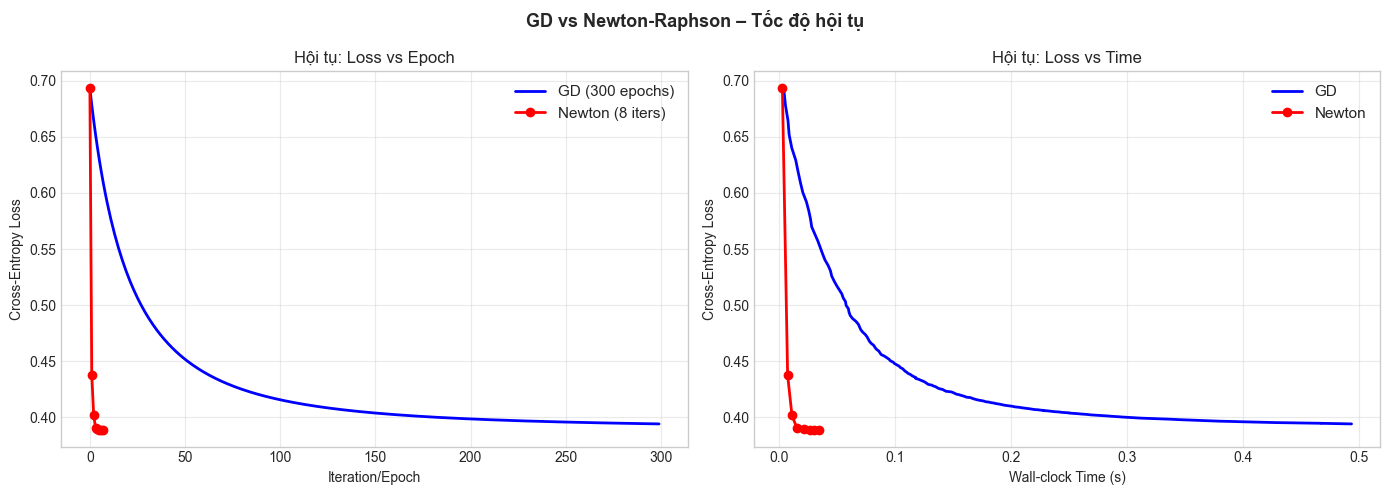

GD: 300 epochs, loss=0.394101, t=0.495s
Newton: 8 iters, loss=0.389090, t=0.037s
Newton nhanh hơn ~38x về số iterations


In [ ]:
# Convergence comparison: GD vs Newton
plot_gd_newton_convergence(lr_gd, lr_nr)

### 4.3 Lý thuyết – Multi-class Softmax

> **📌 Ghi chú dataset:** Phần này dùng **synthesis data** (3 lớp, từ `make_classification`) thay vì adult.csv, vì adult là bài toán **nhị phân**. Synthesis data cho phép so sánh 3 chiến lược một cách công bằng với ground-truth 3 lớp rõ ràng.

---

#### 1. Softmax Function (Generalization của Sigmoid)

Với $K$ lớp, mô hình Softmax Regression dự đoán xác suất thuộc mỗi lớp:

$$P(y=k|x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^K e^{\theta_j^T x}}$$

**Ký hiệu:**
- $K$ — số lớp (classes)
- $\theta_k \in \mathbb{R}^{D+1}$ — vector tham số riêng cho lớp $k$ (đã augment bias)
- $\Theta \in \mathbb{R}^{(D+1) \times K}$ — **parameter matrix**: mỗi cột $\theta_k$ là tham số của lớp $k$
- Tổng $\sum_{j=1}^K e^{\theta_j^T x}$ — **normalization constant** (hàm phân hoạch): đảm bảo tổng xác suất bằng 1
- Khi $K=2$: Softmax rút gọn về **Sigmoid** (logistic regression nhị phân)

**Tính chất quan trọng:**
- $P(y=k|x) \in (0,1)$ và $\sum_k P(y=k|x) = 1$ → là phân phối xác suất hợp lệ
- **Softmax nhạy với nhiễu số học:** khi $\theta_k^T x$ lớn, $e^{\theta_k^T x}$ có thể overflow → cần **log-sum-exp trick**: $\log \sum_k e^{z_k} = c + \log \sum_k e^{z_k - c}$ với $c = \max_k z_k$

---

#### 2. Jacobian của Softmax

Với vector $s = \text{softmax}(z) \in \mathbb{R}^K$ (đầu ra của softmax cho input $z$):

$$\frac{\partial s_k}{\partial z_j} = \begin{cases} s_k(1-s_k) & j=k \\ -s_k s_j & j\neq k \end{cases}
\quad\Rightarrow\quad J_s = \mathrm{diag}(s) - ss^T \in \mathbb{R}^{K\times K}$$

**Ký hiệu:**
- $\frac{\partial s_k}{\partial z_j}$ — đạo hàm riêng của output $s_k$ theo input $z_j$
- $J_s$ — **Jacobian matrix** ($K \times K$): ma trận đầy đủ các đạo hàm riêng
- $\mathrm{diag}(s)$ — ma trận đường chéo với $s$ trên đường chéo chính
- $ss^T$ — ma trận rank-1 (outer product): $[ss^T]_{jk} = s_j s_k$
- Phần tử diagonal $[J_s]_{kk} = s_k(1-s_k)$ — giống sigmoid variance (**phần đóng góp của chính lớp $k$**)
- Phần tử off-diagonal $[J_s]_{jk} = -s_j s_k$ — **âm** vì tăng xác suất lớp $j$ → giảm xác suất lớp $k$

---

#### 3. Hàm mất mát – Categorical Cross-Entropy

$$J(\Theta) = -\frac{1}{m}\sum_{i=1}^m \sum_{k=1}^K y_{ik} \log P(y=k|x^{(i)})$$

**Ký hiệu:**
- $y_{ik} \in \{0,1\}$ — **one-hot encoding**: $y_{ik}=1$ nếu mẫu $i$ thuộc lớp $k$, bằng 0 nếu ngược lại
- Ký hiệu ma trận: $Y_{\text{one-hot}} \in \mathbb{R}^{m \times K}$, mỗi hàng chứa đúng một số 1

---

#### 4. Gradient của Loss w.r.t. $\Theta$

$$\nabla_{\Theta} J = \frac{1}{m} X^T (\hat{Y} - Y_{\text{one-hot}}) \in \mathbb{R}^{(D+1)\times K}$$

**Ký hiệu:**
- $\hat{Y} \in \mathbb{R}^{m \times K}$ — ma trận **predicted probabilities**: $\hat{Y}_{ik} = P(y=k|x^{(i)})$
- $(\hat{Y} - Y_{\text{one-hot}}) \in \mathbb{R}^{m \times K}$ — ma trận **residuals** (sai số dự đoán)
- $X^T (\hat{Y} - Y_{\text{one-hot}})$ — gradient tổng hợp: mỗi cột tương ứng với một lớp $k$

---

#### 5. Hessian – So sánh Binary và Softmax

**Binary Hessian** (section 4.2):
$$H = \frac{1}{m}X^T D X \in \mathbb{R}^{(D+1)\times(D+1)}, \quad D_{ii}=h_i(1-h_i)$$

**Softmax Hessian** (Block Matrix với $K$ lớp):

Tham số $\Theta \in \mathbb{R}^{(D+1)\times K}$, Hessian là **block matrix** $K(D+1)\times K(D+1)$:

$$H = \begin{bmatrix} H_{11} & H_{12} & \cdots & H_{1K} \\ H_{21} & H_{22} & \cdots & H_{2K} \\ \vdots & & \ddots & \vdots \\ H_{K1} & H_{K2} & \cdots & H_{KK} \end{bmatrix}$$

Mỗi block $(j,k)$ có kích thước $(D+1)\times(D+1)$:

$$H_{jk} = \frac{1}{m} X^T D_{jk} X, \quad D_{jk} = \mathrm{diag}\!\left(p_j^{(i)}\bigl(\delta_{jk} - p_k^{(i)}\bigr)\right)$$

trong đó $p_k^{(i)} = P(y=k|x^{(i)})$ và $\delta_{jk}$ là **Kronecker delta** ($=1$ nếu $j=k$, $=0$ nếu khác).

> **So sánh chi phí:**
> - **Binary Hessian:** 1 ma trận $(D+1)\times(D+1)$ → tính được nhanh.
> - **Softmax Hessian:** $K\times K$ blocks → tổng kích thước $K(D+1)\times K(D+1)$ → **chi phí $O(K^2 D^2 m)$**, thường quá lớn để tính trực tiếp → dùng GD thay vì Newton cho đa lớp.

---

#### 6. So sánh 3 chiến lược đa lớp

| Chiến lược | #Classifiers | Training | Inference | Ưu điểm |
|-----------|-------------|----------|-----------|---------| 
| **Softmax** | 1 (joint) | Joint GD, $O(K \cdot mD)$/epoch | $O(K \cdot D)$ | Calibrated probability, một lần train |
| **OvR** (One-vs-Rest) | $K$ | Parallel binary, $O(K \cdot mD)$/epoch | $O(K \cdot D)$ | Đơn giản, dễ song song hoá |
| **OvO** (One-vs-One) | $K(K-1)/2$ | Pairwise, mỗi bộ ít data hơn | Voting $O\!\left(\frac{K(K-1)}{2}\right)$ | Ổn định khi $K$ nhỏ, mỗi clf nhẹ |

In [19]:
print("Training multi-class models (Synthesis 3-class)...")
t0=time.time(); sm_clf = SoftmaxRegression(learning_rate=0.1,n_iterations=300); sm_clf.fit(X_syn_tr_sc,y_syn_tr); t_sm=time.time()-t0
t0=time.time(); ovr_clf = OneVsRestClassifier(learning_rate=0.1,n_iterations=200); ovr_clf.fit(X_syn_tr_sc,y_syn_tr); t_ovr=time.time()-t0
t0=time.time(); ovo_clf = OneVsOneClassifier(learning_rate=0.1,n_iterations=200); ovo_clf.fit(X_syn_tr_sc,y_syn_tr); t_ovo=time.time()-t0
print(f"Done – Softmax:{t_sm:.2f}s | OvR:{t_ovr:.2f}s | OvO:{t_ovo:.2f}s")


Training multi-class models (Synthesis 3-class)...
Done – Softmax:0.09s | OvR:0.06s | OvO:0.05s


=== Multi-class Synthesis: 3 Strategies ===
         Accuracy  Precision  Recall      F1
Softmax    0.8400     0.8405  0.8400  0.8387
OvR        0.8167     0.8186  0.8167  0.8142
OvO        0.8333     0.8368  0.8333  0.8311


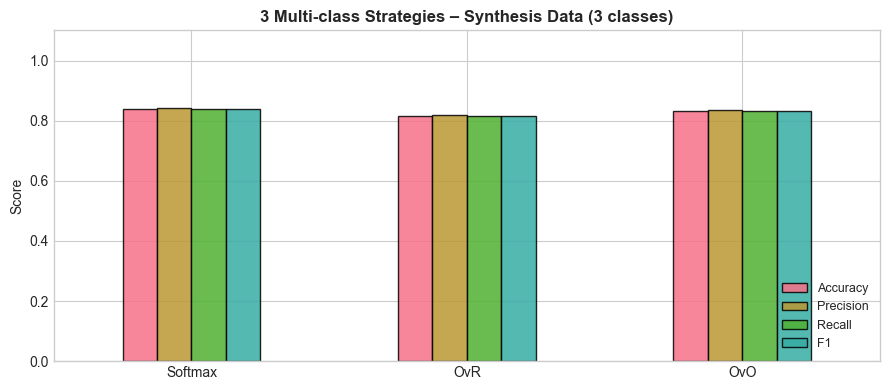

In [20]:
res_mc = {}
for name,clf in [('Softmax',sm_clf),('OvR',ovr_clf),('OvO',ovo_clf)]:
    yp = clf.predict(X_syn_te_sc)
    m = classification_metrics(y_syn_te,yp,average='macro')
    res_mc[name] = {'Accuracy':m['accuracy'],'Precision':m['precision_macro'],'Recall':m['recall_macro'],'F1':m['f1_score_macro']}

df_mc = pd.DataFrame(res_mc).T
print("=== Multi-class Synthesis: 3 Strategies ===")
print(df_mc.round(4).to_string())

fig,ax = plt.subplots(figsize=(9,4))
df_mc.plot(kind='bar',ax=ax,edgecolor='k',alpha=0.85)
ax.set_title('3 Multi-class Strategies – Synthesis Data (3 classes)',fontsize=12,fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0,1.1)
ax.legend(loc='lower right',fontsize=9); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


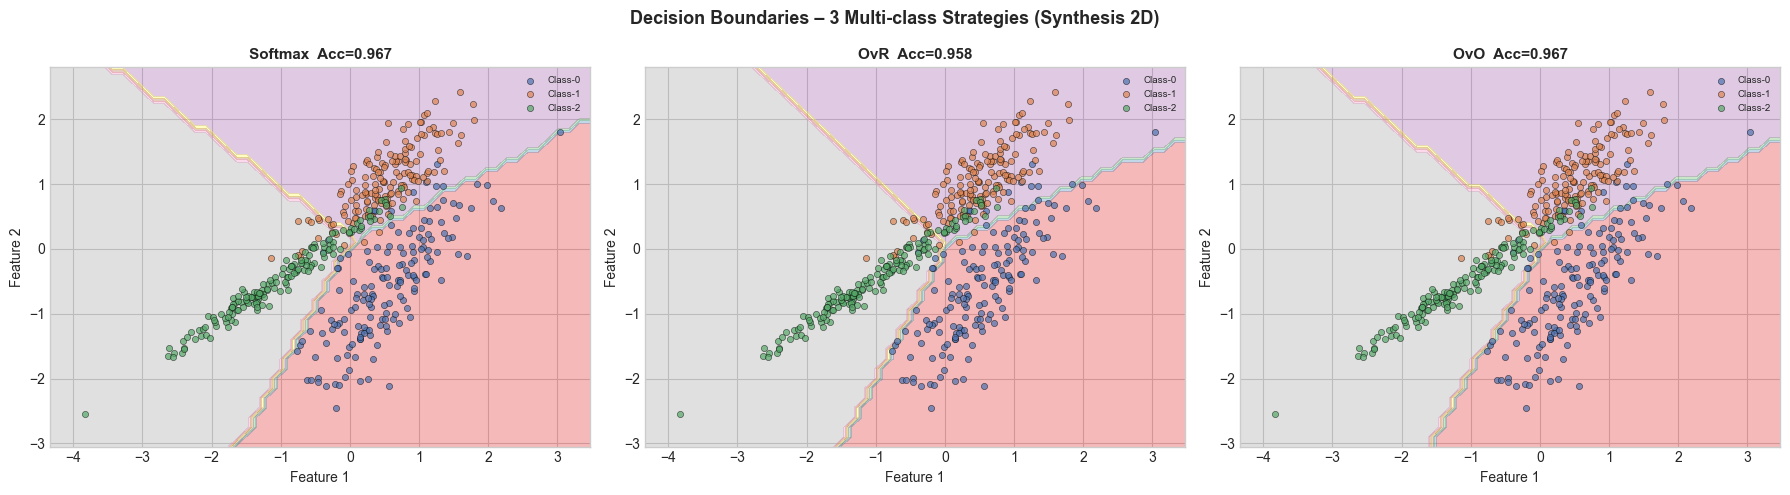

In [21]:
# Decision boundaries 2D – multi-class (using 2D synthesis data)
fig,axes = plt.subplots(1,3,figsize=(18,5))
h=0.15
xmn,xmx = X_syn2d_tr_sc[:,0].min()-0.5, X_syn2d_tr_sc[:,0].max()+0.5
ymn,ymx = X_syn2d_tr_sc[:,1].min()-0.5, X_syn2d_tr_sc[:,1].max()+0.5
xx,yy = np.meshgrid(np.arange(xmn,xmx,h),np.arange(ymn,ymx,h))
grid_pts = np.c_[xx.ravel(),yy.ravel()]

# Train 2D classifiers for visualization
sm_2d  = SoftmaxRegression(learning_rate=0.1,n_iterations=300); sm_2d.fit(X_syn2d_tr_sc,y_syn2d_tr)
ovr_2d = OneVsRestClassifier(learning_rate=0.1,n_iterations=200); ovr_2d.fit(X_syn2d_tr_sc,y_syn2d_tr)
ovo_2d = OneVsOneClassifier(learning_rate=0.1,n_iterations=200); ovo_2d.fit(X_syn2d_tr_sc,y_syn2d_tr)

for ax,(name,clf) in zip(axes,[('Softmax',sm_2d),('OvR',ovr_2d),('OvO',ovo_2d)]):
    Z = clf.predict(grid_pts).reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=0.3,cmap='Set1')
    for cls,color,name_c in zip(range(3),syn_colors,class_names):
        mask=y_syn2d_tr==cls
        ax.scatter(X_syn2d_tr_sc[mask,0],X_syn2d_tr_sc[mask,1],
                   c=color,label=name_c,s=20,edgecolors='k',alpha=0.7,linewidths=0.4)
    acc=accuracy_score(y_syn2d_te,clf.predict(X_syn2d_te_sc))
    ax.set_title(f'{name}  Acc={acc:.3f}',fontsize=11,fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2'); ax.legend(fontsize=7)

plt.suptitle('Decision Boundaries – 3 Multi-class Strategies (Synthesis 2D)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


---
## 5. Linear Discriminant Analysis (LDA) & QDA

### 5.1 Lý thuyết

---

#### Ý tưởng chung – Generative Model

LDA và QDA là **generative models**: thay vì học trực tiếp $P(y|x)$ như Logistic Regression, chúng mô hình hóa **class-conditional distribution** $P(x|y=k) \sim \mathcal{N}(\mu_k, \Sigma_k)$ rồi dùng Bayes' theorem:

$$P(y=k|x) = \frac{P(x|y=k)\,P(y=k)}{P(x)}$$

---

#### LDA – Linear Discriminant Analysis

**Giả định:** Mỗi lớp có phân phối Gaussian với **covariance chung** $\hat{\Sigma}$ (homoscedastic).

**Ước lượng các tham số:**
$$\hat{\mu}_k = \frac{1}{N_k}\sum_{i:y_i=k} x_i \qquad \hat{\pi}_k = \frac{N_k}{N}$$
$$\hat{\Sigma} = \frac{1}{N-K}\sum_{k=1}^K\sum_{i:y_i=k}(x_i-\hat{\mu}_k)(x_i-\hat{\mu}_k)^T$$

**Ký hiệu:**
- $N$ — tổng số mẫu training; $N_k$ — số mẫu lớp $k$; $K$ — số lớp
- $\hat{\mu}_k \in \mathbb{R}^D$ — **mean** của lớp $k$
- $\hat{\pi}_k \in (0,1)$ — **prior** của lớp $k$ (tỷ lệ lớp $k$ trong training)
- $\hat{\Sigma} \in \mathbb{R}^{D\times D}$ — **shared covariance matrix**, được pooled từ tất cả các lớp
- $(N-K)$ ở mẫu số — điều chỉnh bậc tự do (unbiased estimate)

**Hàm discriminant tuyến tính** (linear vì $\hat{\Sigma}$ chung):
$$\delta_k(x) = x^T\hat{\Sigma}^{-1}\hat{\mu}_k - \frac{1}{2}\hat{\mu}_k^T\hat{\Sigma}^{-1}\hat{\mu}_k + \ln\hat{\pi}_k$$

**Ký hiệu:**
- $\hat{\Sigma}^{-1}$ — **precision matrix** (nghịch đảo covariance)
- Số hạng 1: $x^T\hat{\Sigma}^{-1}\hat{\mu}_k$ — **linear term** trong $x$ → tạo **decision boundary tuyến tính**
- Số hạng 2: $-\frac{1}{2}\hat{\mu}_k^T\hat{\Sigma}^{-1}\hat{\mu}_k$ — hằng số phụ thuộc lớp $k$ (khoảng cách Mahalanobis của mean đến gốc)
- Số hạng 3: $\ln\hat{\pi}_k$ — điều chỉnh theo prior (lớp nhiều mẫu hơn được "ưu tiên")

**Quyết định:** $\hat{y} = \arg\max_k \delta_k(x)$

---

#### QDA – Quadratic Discriminant Analysis

**Giả định:** Mỗi lớp có **covariance riêng** $\hat{\Sigma}_k$ (heteroscedastic).

**Hàm discriminant bậc hai** (quadratic vì $\hat{\Sigma}_k$ riêng mỗi lớp):
$$\delta_k(x) = -\frac{1}{2}\ln|\hat{\Sigma}_k| - \frac{1}{2}(x-\hat{\mu}_k)^T\hat{\Sigma}_k^{-1}(x-\hat{\mu}_k) + \ln\hat{\pi}_k$$

**Ký hiệu:**
- $|\hat{\Sigma}_k|$ — **determinant** của $\hat{\Sigma}_k$: phạt lớp có covariance phân tán rộng
- $(x-\hat{\mu}_k)^T\hat{\Sigma}_k^{-1}(x-\hat{\mu}_k)$ — **khoảng cách Mahalanobis** bình phương từ $x$ đến center lớp $k$; tính đến hướng phân tán của dữ liệu (vs. Euclidean distance bỏ qua correlation)
- Khi $\hat{\Sigma}_k = \hat{\Sigma}$ (giống nhau), QDA rút gọn về LDA (phần $\ln|\hat{\Sigma}_k|$ trở thành hằng số)

---

#### Fisher Discriminant Ratio

Đo mức độ **phân biệt lớp** của feature $j$ đơn lẻ:

$$J_j = \frac{\underbrace{\sum_k N_k(\mu_{kj}-\mu_j)^2}_{\text{Between-class variance}}\ }{\underbrace{\sum_k\sum_{i:y_i=k}(x_{ij}-\mu_{kj})^2}_{\text{Within-class variance}}}$$

**Ký hiệu:**
- $\mu_{kj}$ — giá trị **trung bình** của feature $j$ trong lớp $k$
- $\mu_j$ — giá trị **trung bình tổng** của feature $j$ (toàn bộ dataset)
- Tử số: **between-class variance** — feature $j$ phân tách các lớp tốt đến đâu
- Mẫu số: **within-class variance** — mức độ phân tán của feature $j$ trong từng lớp
- $J_j$ lớn → feature $j$ **phân biệt lớp tốt** (giá trị trong các lớp tập trung, giá trị giữa các lớp cách xa nhau)

---

#### So sánh LDA vs QDA

| | LDA | QDA |
|--|-----|-----|
| Covariance | 1 ma trận chung $\hat{\Sigma}$ | $K$ ma trận riêng $\hat{\Sigma}_k$ |
| Decision boundary | **Tuyến tính** | **Bậc hai** |
| Số tham số | $KD + \frac{D(D+1)}{2} + K-1$ | $KD + K\frac{D(D+1)}{2} + K-1$ |
| Trên Adult ($K=2, D=12$) | **103** params | **181** params |
| Phù hợp khi | $N$ nhỏ, $D$ lớn, covariance đồng nhất | $N$ lớn, covariance thực sự khác nhau giữa các lớp |

In [22]:
lda = LinearDiscriminantAnalysis(); lda.fit(X_tr_sc,y_tr)
qda = QuadraticDiscriminantAnalysis(); qda.fit(X_tr_sc,y_tr)

y_pred_lda=lda.predict(X_te_sc); y_proba_lda=lda.predict_proba(X_te_sc)[:,1]
y_pred_qda=qda.predict(X_te_sc); y_proba_qda=qda.predict_proba(X_te_sc)[:,1]

m_lda=classification_metrics(y_te,y_pred_lda,average='binary')
m_qda=classification_metrics(y_te,y_pred_qda,average='binary')

print("=== LDA ==="); [print(f"  {k}: {v:.4f}") for k,v in m_lda.items()]
print("=== QDA ==="); [print(f"  {k}: {v:.4f}") for k,v in m_qda.items()]

D=X_tr_sc.shape[1]; K=2
lda_params = K*D + D*(D+1)//2 + K-1
qda_params_n = K*D + K*D*(D+1)//2 + K-1
print(f"\nLDA params: {lda_params} | QDA params: {qda_params_n} (ratio: {qda_params_n/lda_params:.1f}x)")


=== LDA ===
  precision: 0.7151
  recall: 0.3858
  f1_score: 0.5012
  accuracy: 0.8151
=== QDA ===
  precision: 0.6813
  recall: 0.2972
  f1_score: 0.4139
  accuracy: 0.7973

LDA params: 103 | QDA params: 181 (ratio: 1.8x)


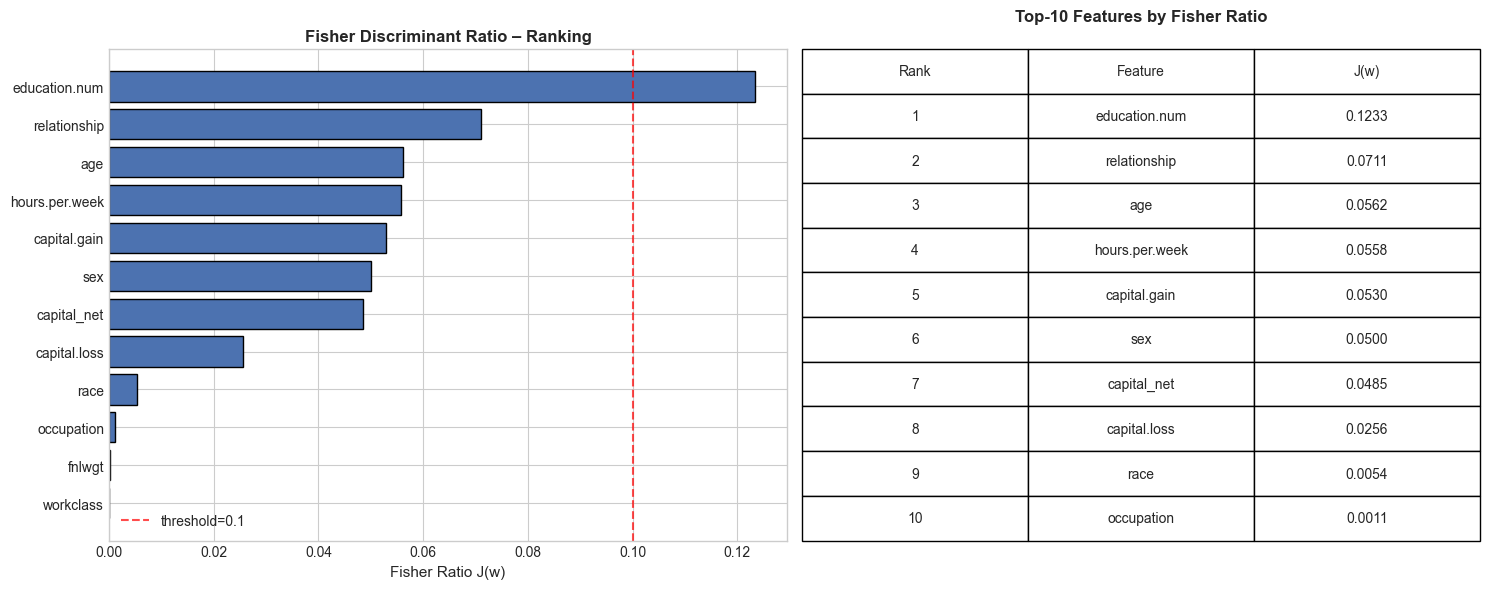

In [23]:
# Fisher ratios
fisher_ratios = lda.compute_fisher_ratios(X_tr_sc,y_tr)
fr_df = pd.DataFrame({'Feature':feature_names,'Fisher Ratio':fisher_ratios}).sort_values('Fisher Ratio',ascending=False)

fig,axes = plt.subplots(1,2,figsize=(15,6))
axes[0].barh(fr_df['Feature'][::-1],fr_df['Fisher Ratio'][::-1],
             color=['#DD8452' if v>0.3 else '#4C72B0' for v in fr_df['Fisher Ratio'][::-1]], edgecolor='k')
axes[0].set_xlabel('Fisher Ratio J(w)',fontsize=11)
axes[0].set_title('Fisher Discriminant Ratio – Ranking',fontsize=12,fontweight='bold')
axes[0].axvline(0.1,color='r',ls='--',alpha=0.7,label='threshold=0.1'); axes[0].legend()

axes[1].axis('off')
tbl = [['Rank','Feature','J(w)']] + [[i+1,r['Feature'],f"{r['Fisher Ratio']:.4f}"] for i,(_,r) in enumerate(fr_df.head(10).iterrows())]
t=axes[1].table(cellText=tbl[1:],colLabels=tbl[0],cellLoc='center',loc='center',bbox=[0,0,1,1])
t.auto_set_font_size(False); t.set_fontsize(10)
axes[1].set_title('Top-10 Features by Fisher Ratio',fontsize=12,fontweight='bold',pad=20)
plt.tight_layout(); plt.show()


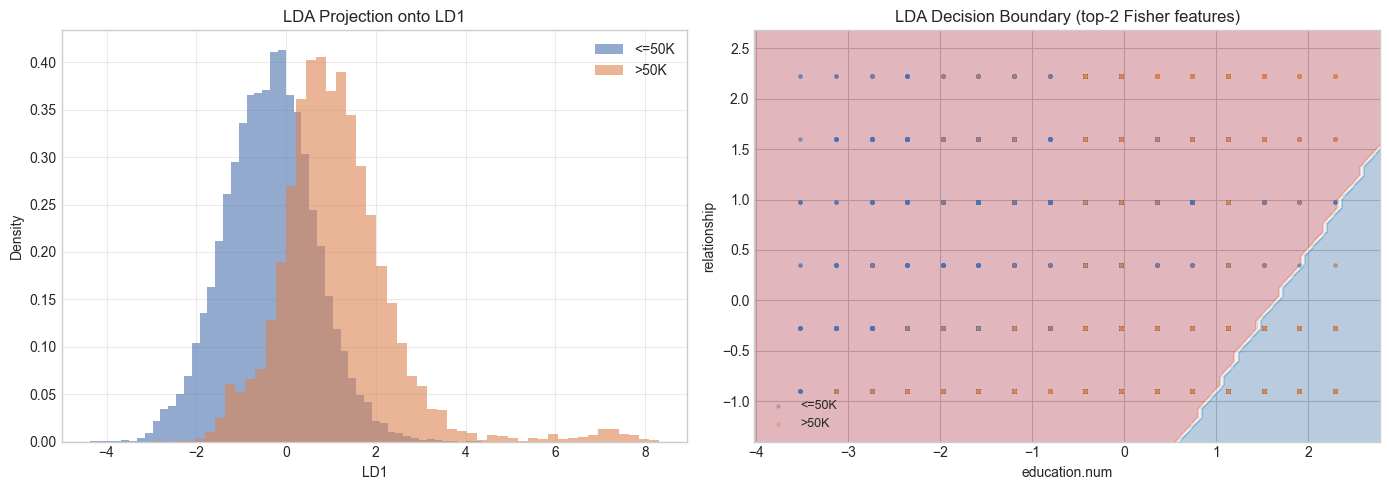

In [24]:
# LDA 2D projection + decision boundary
top2_fisher = np.argsort(fisher_ratios)[::-1][:2]
Xf_tr = X_tr_sc[:,top2_fisher]; Xf_te = X_te_sc[:,top2_fisher]
feat_f = [feature_names[i] for i in top2_fisher]

lda_2d = LinearDiscriminantAnalysis(); lda_2d.fit(Xf_tr,y_tr)

fig,axes = plt.subplots(1,2,figsize=(14,5))

# LD1 histogram
X_ld1_tr = lda.transform(X_tr_sc,n_components=1)
for cls,color,lbl in [(0,'#4C72B0','<=50K'),(1,'#DD8452','>50K')]:
    axes[0].hist(X_ld1_tr[y_tr==cls,0],bins=50,alpha=0.6,color=color,label=lbl,density=True)
axes[0].set(xlabel='LD1',ylabel='Density',title='LDA Projection onto LD1')
axes[0].legend(); axes[0].grid(alpha=0.4)

# Decision boundary 2D
h=0.08
xmn,xmx = Xf_tr[:,0].min()-0.5,Xf_tr[:,0].max()+0.5
ymn,ymx = Xf_tr[:,1].min()-0.5,Xf_tr[:,1].max()+0.5
xx,yy=np.meshgrid(np.arange(xmn,xmx,h),np.arange(ymn,ymx,h))
Z=lda_2d.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx,yy,Z,alpha=0.3,cmap='RdBu')
for cls,color,lbl in [(0,'#4C72B0','<=50K'),(1,'#DD8452','>50K')]:
    mask=y_tr==cls
    axes[1].scatter(Xf_tr[mask,0],Xf_tr[mask,1],c=color,label=lbl,s=5,alpha=0.3)
axes[1].set(xlabel=feat_f[0],ylabel=feat_f[1],title=f'LDA Decision Boundary (top-2 Fisher features)')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


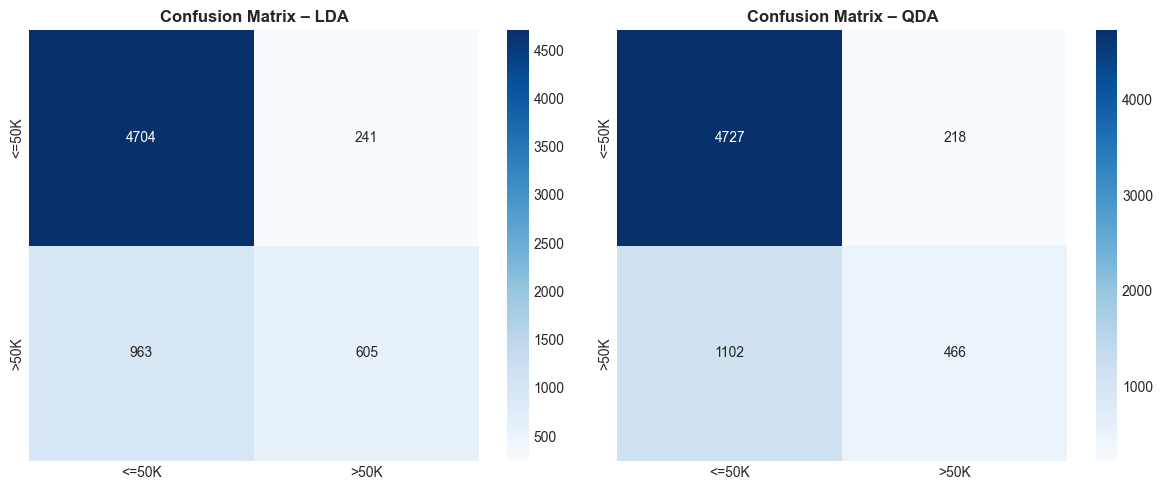

N=22792, D=12, N/D ratio=1899

Phân tích LDA vs QDA:
  LDA params: 103
  QDA params: 181
  LDA tốt hơn khi N/D nhỏ → ít tham số, ít overfitting covariance.
  QDA tốt hơn khi covariance thực sự khác nhau & N đủ lớn.
  Trên Adult: N=22792>>D=12 nên QDA ổn định, nhưng adult có covariance khá đồng nhất → LDA≈QDA.


In [25]:
# LDA vs QDA confusion matrices + analysis
fig,axes = plt.subplots(1,2,figsize=(12,5))
for ax,(name,yp) in zip(axes,[('LDA',y_pred_lda),('QDA',y_pred_qda)]):
    cm=custom_cm(y_te,yp,n_classes=2)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=['<=50K','>50K'],yticklabels=['<=50K','>50K'])
    ax.set_title(f'Confusion Matrix – {name}',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

N=len(X_tr_sc); D=X_tr_sc.shape[1]
print(f"N={N}, D={D}, N/D ratio={N/D:.0f}")
print(f"\nPhân tích LDA vs QDA:")
print(f"  LDA params: {K*D+D*(D+1)//2+K-1}")
print(f"  QDA params: {K*D+K*D*(D+1)//2+K-1}")
print(f"  LDA tốt hơn khi N/D nhỏ → ít tham số, ít overfitting covariance.")
print(f"  QDA tốt hơn khi covariance thực sự khác nhau & N đủ lớn.")
print(f"  Trên Adult: N={N}>>D={D} nên QDA ổn định, nhưng adult có covariance khá đồng nhất → LDA≈QDA.")


---
## 6. Perceptron & Logistic Regression với Regularization

### 6.1 Lý thuyết – Perceptron

---

#### Mô hình

$$f(x) = \text{sign}(w^T x + b), \qquad y_i \in \{-1, +1\}$$

**Ký hiệu:**
- $w \in \mathbb{R}^D$ — vector trọng số (normal vector của hyperplane phân cách)
- $b \in \mathbb{R}$ — bias (offset của hyperplane khỏi gốc tọa độ)
- $\text{sign}(z) = +1$ nếu $z > 0$, $-1$ nếu $z \leq 0$
- Nhãn dùng $\{-1, +1\}$ (thay vì $\{0,1\}$) để luật cập nhật trở nên gọn hơn

> **Trực giác hình học:** Perceptron tìm **hyperplane** $w^T x + b = 0$ phân chia không gian đặc trưng thành 2 nửa. Điểm nằm cùng phía với $w$ → dự đoán $+1$, ngược phía → dự đoán $-1$.

---

#### Luật cập nhật (Perceptron Update Rule)

**Điều kiện kích hoạt cập nhật** — khi mẫu $i$ bị phân lớp **sai**:

$$y_i f(x_i) = y_i \cdot \text{sign}(w^T x_i + b) \leq 0$$

**Cập nhật:**

$$w \leftarrow w + \eta \, y_i x_i, \qquad b \leftarrow b + \eta \, y_i$$

**Ký hiệu:**
- $\eta > 0$ — learning rate (thường $\eta = 1$ trong perceptron cổ điển)
- $y_i x_i$ — nếu $y_i = +1$: dịch $w$ về phía $x_i$ (đẩy hyperplane ra xa phía $x_i$); nếu $y_i = -1$: dịch $w$ ngược phía $x_i$
- Không cập nhật nếu phân lớp **đúng** ($y_i f(x_i) > 0$)

> **Tại sao luật này hoạt động?** Sau khi cập nhật, $w_{\text{new}}^T x_i = (w + \eta y_i x_i)^T x_i = w^T x_i + \eta y_i \|x_i\|^2$. Vì $y_i \|x_i\|^2 > 0$ với $y_i = +1$, linear predictor tại $x_i$ **tăng** → đúng hướng.

---

#### Định lý Hội tụ Perceptron (Novikoff, 1962)

Nếu data **linearly separable** với margin $\gamma > 0$ và $R = \max_i \|x_i\|$, thì số bước cập nhật:

$$T \leq \left(\frac{R}{\gamma}\right)^2$$

**Ký hiệu:**
- $\gamma > 0$ — **functional margin**: khoảng cách nhỏ nhất từ bất kỳ điểm nào đến hyperplane tối ưu. $\gamma$ lớn → data "dễ phân"
- $R = \max_i \|x_i\|$ — bán kính của quả cầu bao quanh toàn bộ dữ liệu
- $T$ — số lần cập nhật (không phải số epochs)
- $(R/\gamma)^2$ — bound hữu hạn → **đảm bảo hội tụ** sau số bước hữu hạn

**Điều kiện:** Định lý **chỉ áp dụng** khi data linearly separable. Nếu không separable → perceptron **không bao giờ hội tụ** (oscillate mãi).

---

#### Giới hạn của Perceptron

| Tình huống | Kết quả |
|-----------|---------|
| Linearly separable | Hội tụ sau tối đa $(R/\gamma)^2$ bước cập nhật |
| Non-linearly separable | Không hội tụ (số lỗi không về 0) |
| Nhiều nghiệm tối ưu | Perceptron có thể tìm **bất kỳ** hyperplane nào phân tách được (không phải max-margin như SVM) |

> **Khắc phục:** Kernel Perceptron (dùng kernel trick), SVM (tìm max-margin hyperplane), hoặc Logistic Regression (output xác suất, robust hơn với noise).

In [26]:
from sklearn.datasets import make_classification, make_moons

# Linearly separable data
X_lin, y_lin = make_classification(n_samples=300,n_features=2,n_redundant=0,
                                   n_clusters_per_class=1,class_sep=2.5,random_state=42)
sc_lin = StandardScaler(); X_lin_sc = sc_lin.fit_transform(X_lin)

# Non-linearly separable (moons)
X_nl, y_nl = make_moons(n_samples=300,noise=0.25,random_state=42)
sc_nl = StandardScaler(); X_nl_sc = sc_nl.fit_transform(X_nl)

perc_lin = Perceptron(learning_rate=0.01,n_iterations=100); perc_lin.fit(X_lin_sc,y_lin)
perc_nl  = Perceptron(learning_rate=0.01,n_iterations=100); perc_nl.fit(X_nl_sc,y_nl)

print(f"Linearly separable – final errors: {perc_lin.errors[-1]}, epochs: {len(perc_lin.errors)}")
print(f"Non-linear (moons) – final errors: {perc_nl.errors[-1]} (không về 0)")


Converged at iteration 2
Linearly separable – final errors: 0, epochs: 2
Non-linear (moons) – final errors: 64 (không về 0)


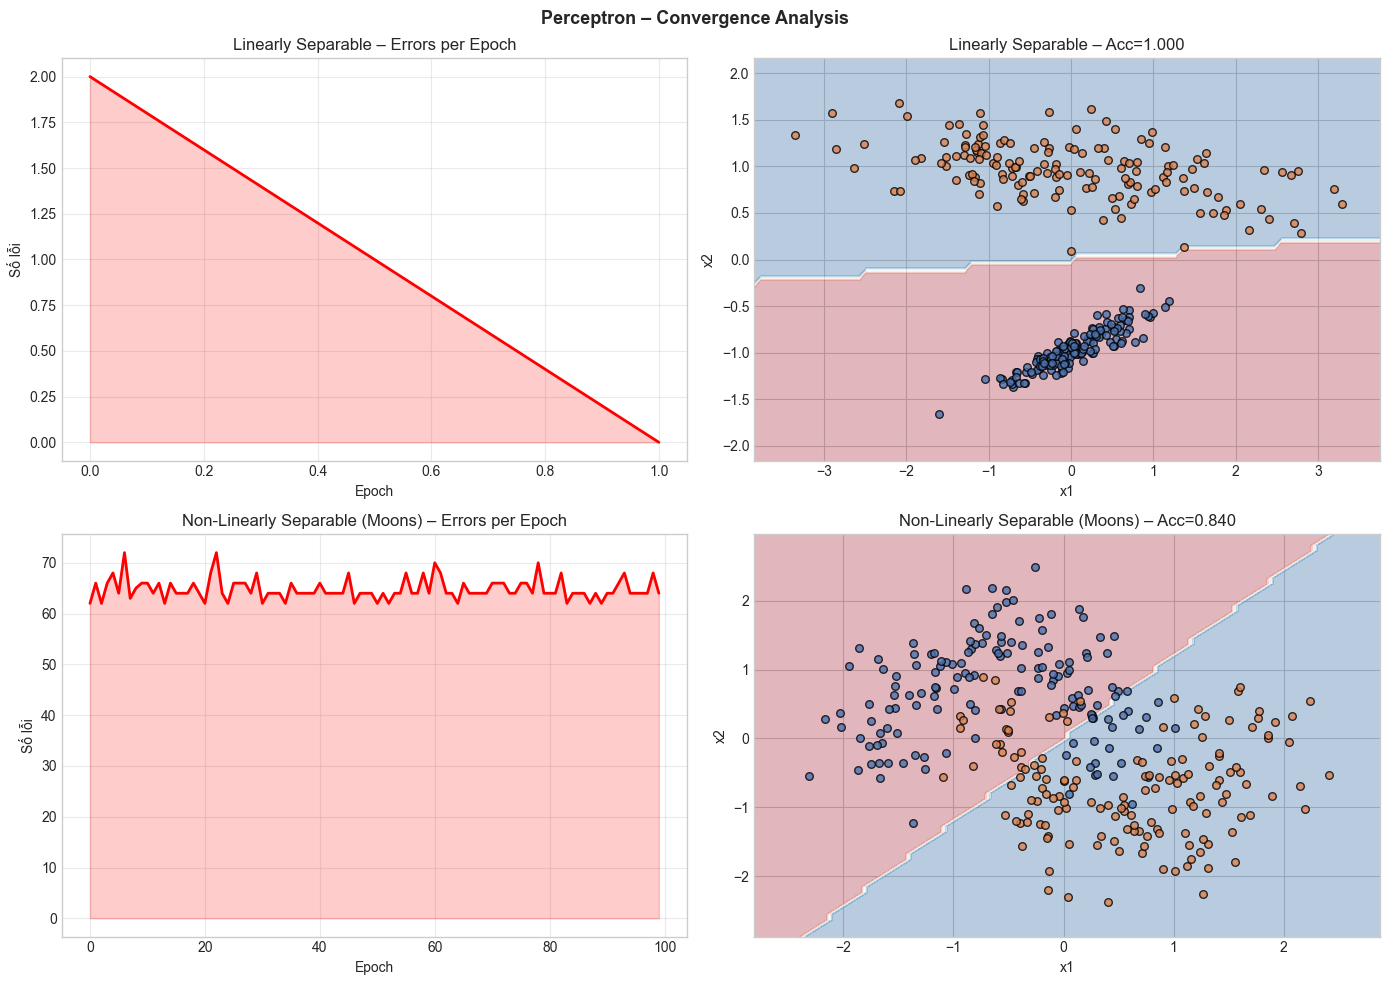

In [27]:
fig,axes = plt.subplots(2,2,figsize=(14,10))
for row,(X,y,perc,title) in enumerate([
    (X_lin_sc,y_lin,perc_lin,'Linearly Separable'),
    (X_nl_sc,y_nl,perc_nl,'Non-Linearly Separable (Moons)')
]):
    axes[row,0].plot(perc.errors,'r-',lw=2)
    axes[row,0].fill_between(range(len(perc.errors)),perc.errors,alpha=0.2,color='red')
    axes[row,0].set(xlabel='Epoch',ylabel='Số lỗi',title=f'{title} – Errors per Epoch')
    axes[row,0].grid(alpha=0.4)

    h=0.08; xm,xM=X[:,0].min()-.5,X[:,0].max()+.5; ym,yM=X[:,1].min()-.5,X[:,1].max()+.5
    xx,yy=np.meshgrid(np.arange(xm,xM,h),np.arange(ym,yM,h))
    Z=perc.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    axes[row,1].contourf(xx,yy,Z,alpha=0.3,cmap='RdBu')
    for cls,color in [(0,'#4C72B0'),(1,'#DD8452')]:
        mask=y==cls; axes[row,1].scatter(X[mask,0],X[mask,1],c=color,s=30,edgecolors='k',alpha=0.8)
    acc=accuracy_score(y,perc.predict(X))
    axes[row,1].set(xlabel='x1',ylabel='x2',title=f'{title} – Acc={acc:.3f}')

plt.suptitle('Perceptron – Convergence Analysis',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


### 6.2 Lý thuyết – L1/L2 Regularization & Class-Weighted Loss

---

#### Tại sao cần Regularization?

Không có regularization → mô hình có thể **overfit** training data (weights tăng vô hạn để fit noise). Regularization thêm **penalty** lên độ lớn của weights vào hàm loss, buộc mô hình học các pattern tổng quát hơn.

---

#### L2 Regularization (Ridge)

$$J(\theta) = \underbrace{CE(\theta)}_{\text{cross-entropy}} + \underbrace{\frac{\lambda}{2m}\|\theta_{1:}\|_2^2}_{\text{L2 penalty}}$$

**Gradient** có thêm thành phần regularization:

$$\nabla_\theta J = \frac{1}{m}X^T(h-y) + \frac{\lambda}{m}\theta \quad \text{(bias } \theta_0 \text{ không regularize)}$$

**Ký hiệu:**
- $\lambda > 0$ — **regularization strength**: kiểm soát bias-variance tradeoff. $\lambda \uparrow$ → weights nhỏ hơn → bias tăng, variance giảm
- $\|\theta_{1:}\|_2^2 = \theta_1^2 + \theta_2^2 + \cdots + \theta_D^2$ — **L2 norm bình phương** của weights (bỏ $\theta_0$ vì bias không cần regularize)
- $\frac{1}{2}$ ở mẫu số: để đạo hàm gọn ($\frac{d}{d\theta}(\frac{\lambda}{2m}\theta^2) = \frac{\lambda}{m}\theta$)
- **Hiệu quả:** Weights bị co lại về 0 nhưng **không bao giờ = 0 chính xác** → giữ tất cả features

---

#### L1 Regularization (Lasso)

$$J(\theta) = CE(\theta) + \frac{\lambda}{m}\|\theta_{1:}\|_1$$

**Gradient** (subgradient vì $|\theta|$ không khả vi tại 0):

$$\nabla_\theta J = \frac{1}{m}X^T(h-y) + \frac{\lambda}{m}\text{sign}(\theta)$$

**Ký hiệu:**
- $\|\theta_{1:}\|_1 = |\theta_1| + |\theta_2| + \cdots + |\theta_D|$ — **L1 norm** của weights
- $\text{sign}(\theta_j) = +1$ nếu $\theta_j > 0$, $-1$ nếu $\theta_j < 0$, $0$ nếu $\theta_j = 0$
- **Hiệu quả:** Tạo ra **nghiệm thưa** (sparse solution) — nhiều weights bằng **chính xác 0** → tự động **feature selection**

| | L2 (Ridge) | L1 (Lasso) |
|--|-----------|-----------|
| Penalty shape | Hình cầu (sphere) | Hình kim cương (diamond) |
| Nghiệm | Dense (tất cả weights ≠ 0) | Sparse (nhiều weights = 0) |
| Feature selection | Không | Có (tự động) |
| Phù hợp | Features đều liên quan | Nhiều features không quan trọng |

---

#### Class-Weighted Loss

Với dữ liệu **mất cân bằng** (imbalanced), loss chuẩn bị dominated bởi lớp đa số. Giải pháp: gán **trọng số** $c_k$ cho từng lớp:

$$E = -\sum_{n=1}^{m}\sum_{k=0}^{K-1} c_k \cdot t_{nk} \cdot \ln y_{nk}$$

**Ký hiệu:**
- $t_{nk} \in \{0,1\}$ — **one-hot label**: $t_{nk}=1$ nếu mẫu $n$ thuộc lớp $k$, $=0$ ngược lại
- $y_{nk} \in (0,1)$ — **predicted probability** của mẫu $n$ thuộc lớp $k$
- $c_k$ — **class weight**: $c_k = \frac{N}{K \cdot N_k}$ (tỷ lệ nghịch với kích thước lớp)
  - Lớp thiểu số ($N_k$ nhỏ) → $c_k$ lớn → **penalty cao hơn** khi phân lớp sai lớp thiểu số
  - Lớp đa số ($N_k$ lớn) → $c_k$ nhỏ → ít penalty hơn

> **Trên Adult dataset:** Class 0 (≤50K, 75%): $c_0 \approx 1.3$; Class 1 (>50K, 25%): $c_1 \approx 4.2$ → mỗi lỗi trên lớp thiểu số bị phạt **gấp 3.2× lớp đa số**.

In [28]:
# Train L1/L2/no-reg
models_reg = {
    'No Reg':        RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='none',reg_lambda=0.0),
    'L2 (λ=0.1)':   RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='l2',reg_lambda=0.1),
    'L1 (λ=0.1)':   RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='l1',reg_lambda=0.1),
    'L1 (λ=1.0)':   RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='l1',reg_lambda=1.0),
}
res_reg = {}
for name,clf in models_reg.items():
    clf.fit(X_tr_sc,y_tr)
    yp=clf.predict(X_te_sc); m=classification_metrics(y_te,yp,average='binary')
    nnz=clf.count_nonzero_weights()
    res_reg[name]={'Accuracy':m['accuracy'],'F1':m['f1_score'],'Recall':m['recall'],
                   'Non-zero':nnz,'Sparsity%':100*(1-nnz/len(clf.theta[1:]))}

df_reg = pd.DataFrame(res_reg).T
print("=== L1/L2 Regularization ===")
print(df_reg.round(4).to_string())


=== L1/L2 Regularization ===
            Accuracy      F1  Recall  Non-zero  Sparsity%
No Reg        0.8234  0.5367  0.4247      12.0        0.0
L2 (λ=0.1)    0.8234  0.5367  0.4247      12.0        0.0
L1 (λ=0.1)    0.8234  0.5367  0.4247      12.0        0.0
L1 (λ=1.0)    0.8233  0.5361  0.4241      12.0        0.0


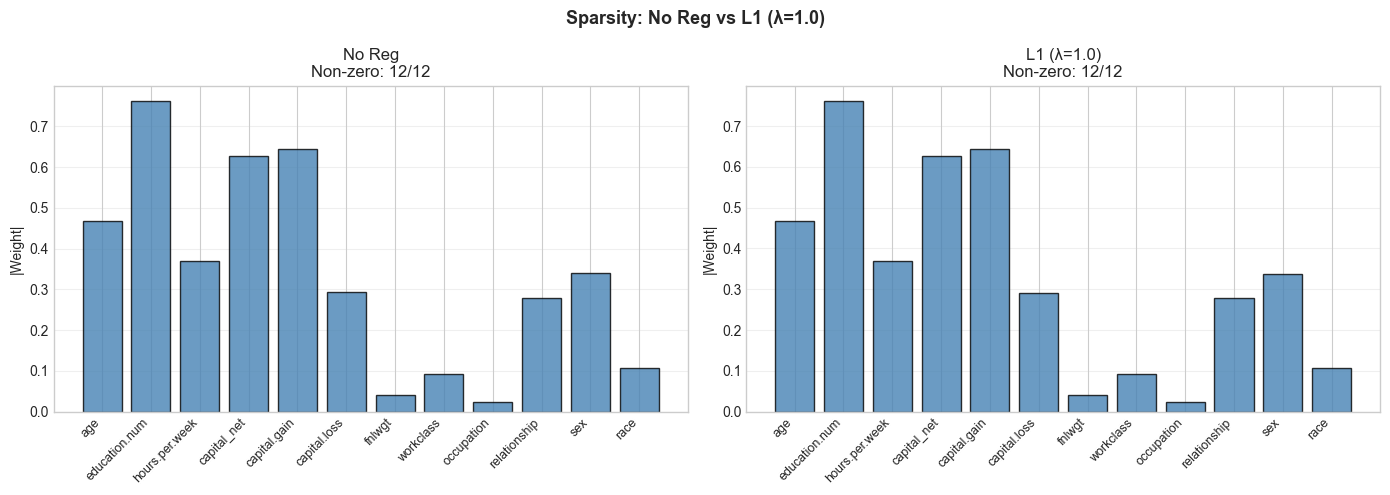

In [29]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
x_pos = np.arange(len(feature_names))
for i,(name,col_idx) in enumerate([('No Reg',0),('L1 (λ=1.0)',3)]):
    clf=list(models_reg.values())[col_idx]
    axes[i].bar(x_pos,np.abs(clf.theta[1:]),color='steelblue',edgecolor='k',alpha=0.8)
    axes[i].set_xticks(x_pos); axes[i].set_xticklabels(feature_names,rotation=45,ha='right',fontsize=9)
    axes[i].set(ylabel='|Weight|',title=f'{name}\nNon-zero: {clf.count_nonzero_weights()}/{len(feature_names)}')
    axes[i].grid(alpha=0.3,axis='y')

plt.suptitle('Sparsity: No Reg vs L1 (λ=1.0)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


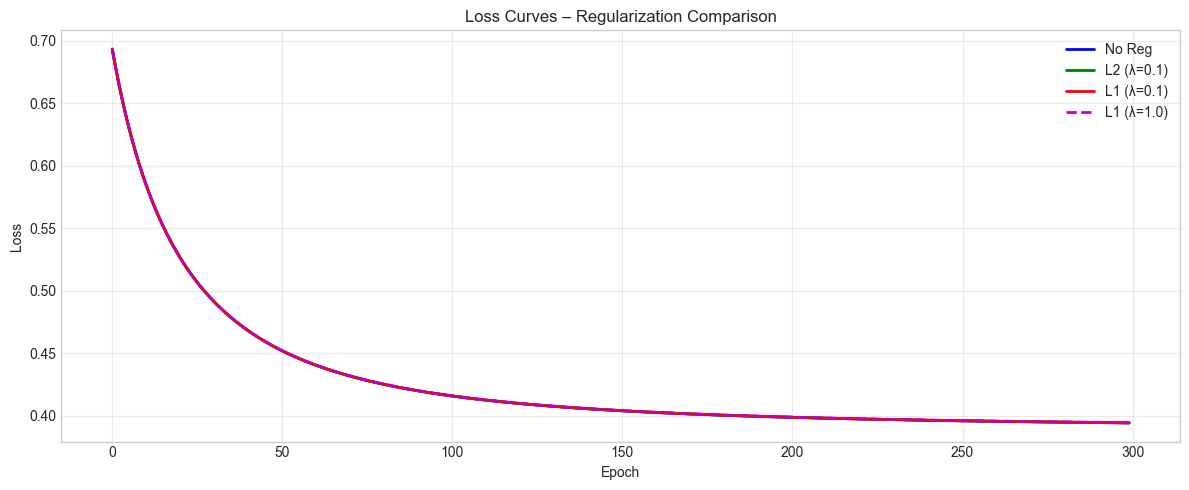

In [30]:
fig,ax=plt.subplots(figsize=(12,5))
styles=['b-','g-','r-','m--']
for (name,clf),sty in zip(models_reg.items(),styles):
    ax.plot(clf.losses,sty,lw=2,label=name)
ax.set(xlabel='Epoch',ylabel='Loss',title='Loss Curves – Regularization Comparison')
ax.legend(fontsize=10); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()


### 6.3 Stratified 5-fold CV chọn λ

In [31]:
lambdas=[0.001,0.005,0.01,0.05,0.1,0.5,1.0,5.0,10.0]
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_res={'l1':{},'l2':{}}

for reg_type in ['l1','l2']:
    print(f"CV {reg_type.upper()}...",end=' ')
    for lam in lambdas:
        f1s=[]
        for tr_i,va_i in kf.split(X_tr_sc,y_tr):
            clf=RegularizedLogisticRegression(learning_rate=0.1,n_iterations=200,
                                              reg_type=reg_type,reg_lambda=lam)
            clf.fit(X_tr_sc[tr_i],y_tr[tr_i])
            yp=clf.predict(X_tr_sc[va_i])
            f1s.append(classification_metrics(y_tr[va_i],yp,average='binary')['f1_score'])
        cv_res[reg_type][lam]={'mean':np.mean(f1s),'std':np.std(f1s)}
    best=max(cv_res[reg_type],key=lambda l:cv_res[reg_type][l]['mean'])
    print(f"Best λ={best}, F1={cv_res[reg_type][best]['mean']:.4f}±{cv_res[reg_type][best]['std']:.4f}")


CV L1... Best λ=0.05, F1=0.5349±0.0114
CV L2... Best λ=0.001, F1=0.5348±0.0114


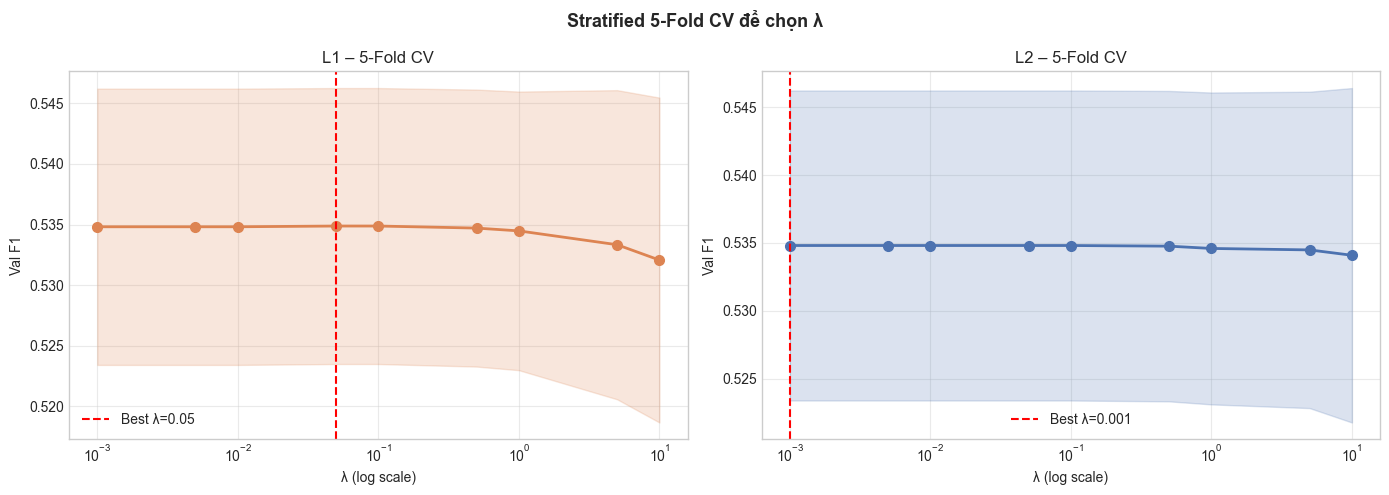

In [32]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,reg_type,color in zip(axes,['l1','l2'],['#DD8452','#4C72B0']):
    ms=[cv_res[reg_type][l]['mean'] for l in lambdas]
    ss=[cv_res[reg_type][l]['std']  for l in lambdas]
    ax.semilogx(lambdas,ms,'o-',color=color,lw=2,ms=7)
    ax.fill_between(lambdas,np.array(ms)-np.array(ss),np.array(ms)+np.array(ss),alpha=0.2,color=color)
    best=max(cv_res[reg_type],key=lambda l:cv_res[reg_type][l]['mean'])
    ax.axvline(best,color='r',ls='--',label=f'Best λ={best}')
    ax.set(xlabel='λ (log scale)',ylabel='Val F1',title=f'{reg_type.upper()} – 5-Fold CV')
    ax.legend(fontsize=10); ax.grid(alpha=0.4)
plt.suptitle('Stratified 5-Fold CV để chọn λ',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


### 6.4 Class-Weighted Loss – Thực nghiệm

**Mục tiêu:** So sánh hiệu năng Logistic Regression **không có** trọng số lớp (unweighted) và **có** trọng số lớp (class-weighted) trên Adult dataset mất cân bằng.

**Lý thuyết tóm tắt** (chi tiết ở Section 6.2):

$$E = -\sum_{n=1}^{m} c_{y_n} \ln P(y=y_n | x_n), \quad c_k = \frac{N}{K \cdot N_k}$$

Với Adult dataset:
- Lớp 0 ($\leq$50K, ~75%): $c_0 \approx 1.32$ (ít bị phạt hơn)
- Lớp 1 ($>$50K, ~25%): $c_1 \approx 4.15$ (bị phạt nặng hơn ~3.2×)

**Kỳ vọng:**
- Unweighted → bias về lớp đa số → **Accuracy cao, Recall của lớp thiểu số thấp**
- Class-weighted → cân bằng hơn → **F1 và Recall của lớp thiểu số cao hơn**, nhưng Accuracy có thể giảm nhẹ

In [33]:
lr_uw=RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='none',reg_lambda=0.0)
lr_uw.fit(X_tr_sc,y_tr); yp_uw=lr_uw.predict(X_te_sc)

lr_w=RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='none',reg_lambda=0.0,class_weight='balanced')
lr_w.fit(X_tr_sc,y_tr); yp_w=lr_w.predict(X_te_sc)

print("=== Class-Weighted vs Unweighted ===")
for name,yp in [('Unweighted',yp_uw),('Class-Weighted (c_k∝N/N_k)',yp_w)]:
    m=classification_metrics(y_te,yp,average='binary')
    print(f"{name}: Acc={m['accuracy']:.4f} F1={m['f1_score']:.4f} Prec={m['precision']:.4f} Rec={m['recall']:.4f}")

c0=len(y_tr)/(y_tr==0).sum(); c1=len(y_tr)/(y_tr==1).sum()
print(f"\nClass weights: c_0={c0:.3f}, c_1={c1:.3f}")
print("→ Class-weighted cải thiện Recall cho lớp thiểu số (>50K)")


=== Class-Weighted vs Unweighted ===
Unweighted: Acc=0.8234 F1=0.5367 Prec=0.7287 Rec=0.4247
Class-Weighted (c_k∝N/N_k): Acc=0.7631 F1=0.6091 Prec=0.5053 Rec=0.7666

Class weights: c_0=1.317, c_1=4.152
→ Class-weighted cải thiện Recall cho lớp thiểu số (>50K)


---
## 7. Bonus Models (+5 điểm)

### 7.1 Probit Regression

---

#### Mô hình

$$P(y=1 \mid x) = \Phi(\theta^T x)$$

**Ký hiệu:**
- $\Phi(z) = \int_{-\infty}^{z} \phi(t)\,dt$ — **Gaussian CDF** (hàm phân phối tích lũy chuẩn)
- $\phi(z) = \frac{1}{\sqrt{2\pi}}e^{-z^2/2}$ — **Gaussian PDF** (mật độ xác suất chuẩn), hay còn gọi là $\mathcal{N}(0,1)$ density
- $\theta^T x$ — linear predictor (tương tự logistic regression)
- $h = \Phi(\theta^T x) \in (0,1)$ — xác suất dự đoán

> **Nguồn gốc:** Probit xuất phát từ mô hình **latent variable**: $y=1$ nếu $\theta^T x + \varepsilon > 0$, với $\varepsilon \sim \mathcal{N}(0,1)$. Khi đó $P(y=1|x) = P(\varepsilon > -\theta^T x) = \Phi(\theta^T x)$.

---

#### Gradient của Cross-Entropy Loss

$$\nabla_\theta J = \frac{1}{m}X^T\left[\frac{(h-y)\,\phi(\theta^T x)}{h(1-h)}\right]$$

**Ký hiệu:**
- $\phi(\theta^T x^{(i)})$ — giá trị **PDF chuẩn** tại điểm $\theta^T x^{(i)}$ (là **đạo hàm của $\Phi$**)
- $h(1-h)$ — **variance Bernoulli**: xuất hiện do chain rule $\frac{dh}{d(\theta^T x)} = \phi(\theta^T x)$
- Phân số $\frac{\phi(\theta^T x)}{h(1-h)}$ — **scale factor**: điều chỉnh độ lớn gradient theo vị trí trên đường cong CDF

**So sánh đạo hàm:**
| | Logistic | Probit |
|--|---------|--------|
| $P(y=1\|x)$ | $\sigma(\theta^T x)$ | $\Phi(\theta^T x)$ |
| $\frac{dh}{d(\theta^T x)}$ | $h(1-h)$ | $\phi(\theta^T x)$ |
| Gradient | $\frac{1}{m}X^T(h-y)$ | $\frac{1}{m}X^T\left[\frac{(h-y)\phi}{h(1-h)}\right]$ |

---

#### Sigmoid vs Probit: Tail Behavior

```
z:          -3      -2      -1       0       1       2       3
σ(z):       0.047   0.119   0.269   0.500   0.731   0.881   0.953  ← heavy tail
Φ(z):       0.001   0.023   0.159   0.500   0.841   0.977   0.999  ← thin tail
```

- **Probit có "thin tail"** (đuôi mỏng hơn sigmoid): xác suất giảm về 0/1 **nhanh hơn** ở vùng xa gốc
- **Hệ quả với label noise:** Một mẫu bị gán nhãn sai (noisy label) ở vùng $|\theta^T x|$ lớn → probit cho xác suất rất gần 0/1 → **loss rất lớn** → **ảnh hưởng mạnh** đến gradient
- Logistic sigmoid có tail béo hơn → "bao dung" hơn với noise → **robust hơn** trong thực tế khi có label noise

> **Kết luận thực nghiệm:** Khi flip ngẫu nhiên $p\%$ nhãn, Probit thường có accuracy thấp hơn Logistic $\approx 1-3\%$ do đuôi mỏng làm gradient bị dominated bởi các mẫu noisy.

=== Probit ===
  precision: 0.7346
  recall: 0.4184
  f1_score: 0.5331
  accuracy: 0.8236


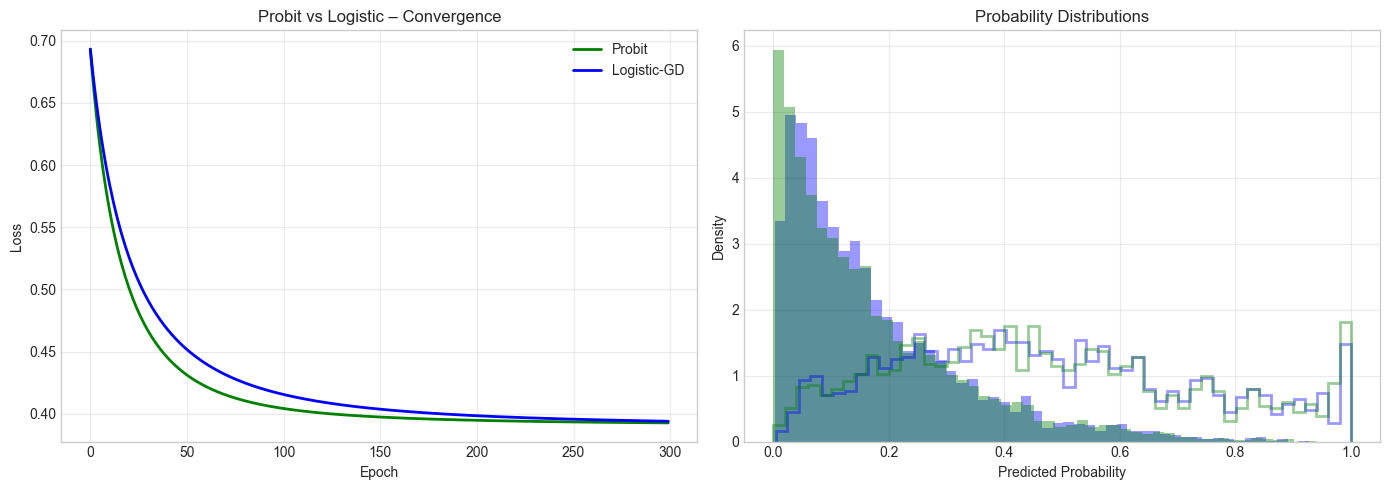

In [34]:
probit=ProbitRegression(learning_rate=0.05,n_iterations=300)
probit.fit(X_tr_sc,y_tr)
yp_probit=probit.predict(X_te_sc); yproba_probit=probit.predict_proba(X_te_sc)
m_probit=classification_metrics(y_te,yp_probit,average='binary')
print("=== Probit ==="); [print(f"  {k}: {v:.4f}") for k,v in m_probit.items()]

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(probit.losses,'g-',lw=2,label='Probit')
axes[0].plot(lr_gd.losses,'b-',lw=2,label='Logistic-GD')
axes[0].set(xlabel='Epoch',ylabel='Loss',title='Probit vs Logistic – Convergence')
axes[0].legend(); axes[0].grid(alpha=0.4)

y_proba_gd=lr_gd.predict_proba(X_te_sc)
for prob_arr,name,color in [(y_proba_gd,'Logistic','b'),(yproba_probit,'Probit','g')]:
    axes[1].hist(prob_arr[y_te==0],bins=50,alpha=0.4,color=color,density=True)
    axes[1].hist(prob_arr[y_te==1],bins=50,alpha=0.4,color=color,density=True,histtype='step',lw=2)
axes[1].set(xlabel='Predicted Probability',ylabel='Density',title='Probability Distributions')
axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()


In [ ]:
# Noise sensitivity: Probit vs Logistic – flip labels at various noise rates
noise_rates = [0.0, 0.05, 0.10, 0.20, 0.30]
results_noise = {'Logistic': [], 'Probit': []}

rng = np.random.default_rng(42)
for nr in noise_rates:
    y_noisy = y_tr.copy()
    if nr > 0:
        flip_idx = rng.choice(len(y_tr), size=int(nr * len(y_tr)), replace=False)
        y_noisy[flip_idx] = 1 - y_noisy[flip_idx]

    clf_lr = LogisticRegressionGD(learning_rate=0.1, n_iterations=200)
    clf_lr.fit(X_tr_sc, y_noisy)
    f1_lr = classification_metrics(y_te, clf_lr.predict(X_te_sc), average='binary')['f1_score']

    clf_pr = ProbitRegression(learning_rate=0.05, n_iterations=200)
    clf_pr.fit(X_tr_sc, y_noisy)
    f1_pr = classification_metrics(y_te, clf_pr.predict(X_te_sc), average='binary')['f1_score']

    results_noise['Logistic'].append(f1_lr)
    results_noise['Probit'].append(f1_pr)

# Print table
print(f"{'Noise':>8} | {'Logistic F1':>12} | {'Probit F1':>10} | {'Δ (Probit-LR)':>14}")
print("-" * 52)
for nr, f1_lr, f1_pr in zip(noise_rates, results_noise['Logistic'], results_noise['Probit']):
    delta = f1_pr - f1_lr
    print(f"{nr*100:7.0f}% | {f1_lr:12.4f} | {f1_pr:10.4f} | {delta:+14.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([r*100 for r in noise_rates], results_noise['Logistic'], 'b-o', lw=2, ms=7, label='Logistic (sigmoid)')
ax.plot([r*100 for r in noise_rates], results_noise['Probit'],   'g-s', lw=2, ms=7, label='Probit (Φ)')
ax.set(xlabel='Label Noise Rate (%)', ylabel='Test F1-score',
       title='Noise Sensitivity: Probit vs Logistic Regression')
ax.legend(fontsize=11); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

print("\n→ Probit dùng Gaussian CDF (tail mỏng hơn sigmoid) → nhạy cảm hơn với outlier/noise label khi noise rate cao.")

### 7.2 Laplace Approximation cho Bayesian Logistic Regression

---

#### Vấn đề: Posterior khó tính

Trong Bayesian framework, **posterior** của tham số $\theta$ sau khi quan sát data $\mathcal{D}$:

$$p(\theta | \mathcal{D}) = \frac{p(\mathcal{D}|\theta)\,p(\theta)}{p(\mathcal{D})}$$

**Ký hiệu:**
- $p(\mathcal{D}|\theta)$ — **likelihood**: xác suất quan sát data nếu tham số là $\theta$
- $p(\theta)$ — **prior**: niềm tin về $\theta$ trước khi quan sát data. Thường dùng $\theta \sim \mathcal{N}(0, \sigma_0^2 I)$
- $p(\mathcal{D}) = \int p(\mathcal{D}|\theta)p(\theta)d\theta$ — **marginal likelihood** (evidence): tích phân này **không có nghiệm giải tích** với logistic likelihood → cần xấp xỉ

---

#### Laplace Approximation

Ý tưởng: **xấp xỉ posterior bằng phân phối Gaussian** quanh điểm MAP:

**Bước 1:** Tìm MAP estimate $\hat{\theta}$ (posterior mode):
$$\hat{\theta} = \arg\max_\theta \ln p(\mathcal{D}|\theta) + \ln p(\theta) = \arg\max_\theta \left[\sum_i \ln p(y_i|x_i,\theta) - \frac{1}{2\sigma_0^2}\|\theta\|^2\right]$$

**Bước 2:** Tính **Hessian** của log-posterior tại $\hat{\theta}$:
$$A = -\nabla^2 \ln p(\theta|\mathcal{D})\big|_{\theta=\hat{\theta}}$$

**Bước 3:** Xấp xỉ posterior:
$$p(\theta|\mathcal{D}) \approx \mathcal{N}(\hat{\theta},\, A^{-1})$$

**Ký hiệu:**
- $\hat{\theta} \in \mathbb{R}^{D+1}$ — **MAP estimate** (Maximum A Posteriori): tham số tối ưu hóa log-posterior
- $A \in \mathbb{R}^{(D+1)\times(D+1)}$ — **precision matrix** của xấp xỉ Gaussian = $-$ Hessian của log-posterior
  - $A = X^T W X + \frac{1}{\sigma_0^2}I$, với $W = \text{diag}(h_i(1-h_i))$ (từ logistic likelihood) và $\frac{1}{\sigma_0^2}I$ từ prior
- $A^{-1}$ — **covariance matrix** của posterior xấp xỉ: đo **uncertainty** về $\theta$

---

#### Predictive Distribution với Uncertainty

Cho input mới $x^*$, **predictive mean**:

$$\bar{h} = \sigma(\hat{\theta}^T x^*)$$

**Predictive variance** (propagating parameter uncertainty):
$$\sigma^2_{x^*} = (x^*)^T A^{-1} x^*$$

**Ký hiệu:**
- $\bar{h} \in (0,1)$ — xác suất dự đoán điểm (point estimate)
- $\sigma^2_{x^*}$ — **variance** của linear predictor $\theta^T x^*$: đo uncertainty tại điểm $x^*$
- **Confidence band** $\approx \bar{h} \pm 2\sigma_{x^*}$ (vùng $\approx 95\%$ credible interval)

> **Ứng dụng:** Vùng gần decision boundary có $\sigma^2_{x^*}$ lớn → mô hình "không chắc chắn" → nên thu thập thêm data hoặc từ chối dự đoán (reject option). Điều này không thể làm được với Logistic Regression thông thường.

---

#### Tóm tắt: Frequentist vs Bayesian LR

| | Logistic Regression (GD/NR) | Bayesian LR (Laplace) |
|--|---------------------------|----------------------|
| Output | $P(y=1\|x;\hat{\theta})$ — điểm | $P(y=1\|x,\mathcal{D})$ — phân phối |
| Uncertainty | Không có | Có (qua $\sigma^2_{x^*}$) |
| Regularization | Explicit $\lambda$ | Implicit qua prior $\sigma_0$ |
| Chi phí | Rẻ | Tốn kém ($O(D^3)$ để nghịch đảo $A$) |

=== Laplace ===
  precision: 0.7298
  recall: 0.4152
  f1_score: 0.5293
  accuracy: 0.8222


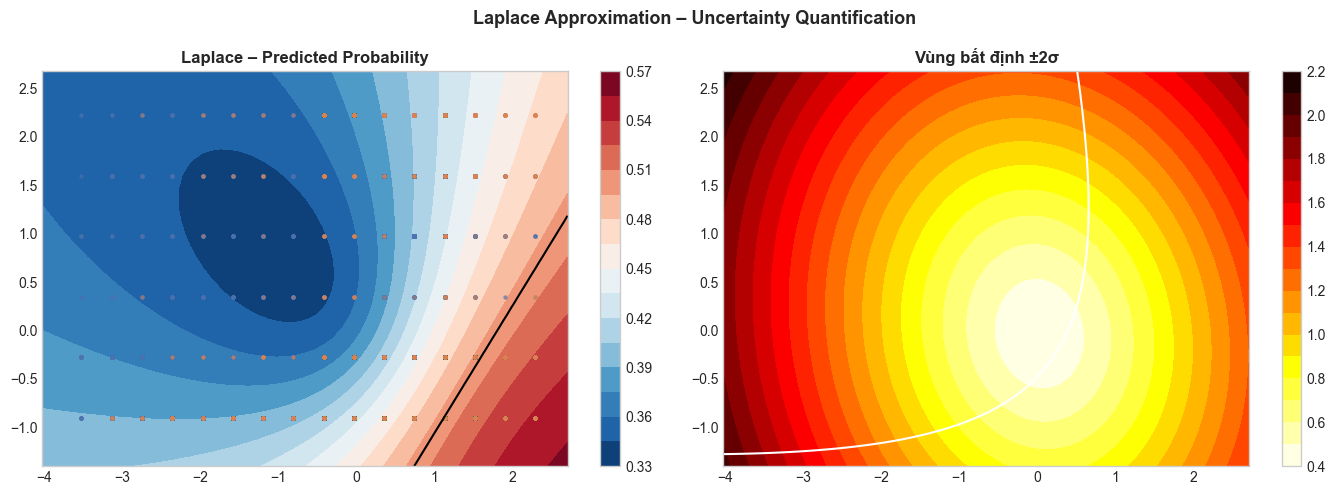

In [35]:
laplace=LogisticRegressionLaplace(learning_rate=0.1,n_iterations=300,prior_variance=10.0)
laplace.fit(X_tr_sc,y_tr)
yp_lap=laplace.predict(X_te_sc); m_lap=classification_metrics(y_te,yp_lap,average='binary')
print("=== Laplace ==="); [print(f"  {k}: {v:.4f}") for k,v in m_lap.items()]

# 2D uncertainty visualization on Fisher-top-2 features
lap2=LogisticRegressionLaplace(learning_rate=0.1,n_iterations=300,prior_variance=10.0)
lap2.fit(Xf_tr,y_tr)

h=0.12; xmn,xmx=Xf_tr[:,0].min()-.5,Xf_tr[:,0].max()+.5; ymn,ymx=Xf_tr[:,1].min()-.5,Xf_tr[:,1].max()+.5
xx,yy=np.meshgrid(np.arange(xmn,xmx,h),np.arange(ymn,ymx,h))
grid=np.c_[xx.ravel(),yy.ravel()]
probs_lap,stds_lap=lap2.predict_with_uncertainty(grid)
probs_lap=probs_lap.reshape(xx.shape); stds_lap=stds_lap.reshape(xx.shape)

fig,axes=plt.subplots(1,2,figsize=(14,5))
im0=axes[0].contourf(xx,yy,probs_lap,levels=20,cmap='RdBu_r'); axes[0].contour(xx,yy,probs_lap,levels=[0.5],colors='k',lw=2)
plt.colorbar(im0,ax=axes[0])
for cls,color in [(0,'#4C72B0'),(1,'#DD8452')]:
    mask=y_tr==cls; axes[0].scatter(Xf_tr[mask,0],Xf_tr[mask,1],c=color,s=5,alpha=0.3)
axes[0].set_title('Laplace – Predicted Probability',fontsize=12,fontweight='bold')

im1=axes[1].contourf(xx,yy,stds_lap,levels=20,cmap='hot_r'); axes[1].contour(xx,yy,probs_lap,levels=[0.4,0.6],colors='w',lw=2,ls='--')
plt.colorbar(im1,ax=axes[1])
axes[1].set_title('Vùng bất định ±2σ',fontsize=12,fontweight='bold')
plt.suptitle('Laplace Approximation – Uncertainty Quantification',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


### 7.3 Kernel Logistic Regression

---

#### Vấn đề của Logistic Regression tuyến tính

Logistic Regression chuẩn học một **hyperplane** $\theta^T x = 0$ — chỉ phân tách được data **linearly separable**. Với XOR, vòng tròn, hay cấu trúc non-linear → cần **feature mapping** lên không gian chiều cao hơn.

---

#### Kernel Trick

Thay vì ánh xạ tường minh $x \mapsto \phi(x)$ (có thể vô hạn chiều), ta sử dụng **kernel function**:

$$\kappa(x, x') = \langle \phi(x), \phi(x') \rangle$$

để tính tích vô hướng trong feature space **mà không cần tính $\phi(x)$ tường minh**.

**Kernel phổ biến:**
- **RBF (Gaussian):** $\kappa(x,x') = \exp\!\left(-\frac{\|x-x'\|^2}{2\sigma^2}\right)$
  - $\sigma > 0$ — **bandwidth**: kiểm soát "độ rộng" của hàm cơ sở Gaussian
  - $\sigma$ nhỏ → kernel cục bộ (local) → dễ overfit; $\sigma$ lớn → smooth → giống linear
- **Polynomial:** $\kappa(x,x') = (x^T x' + c)^d$
- **Linear:** $\kappa(x,x') = x^T x'$ → tương đương logistic thông thường

---

#### Biểu diễn Dual (Representer Theorem)

Theo **Representer Theorem**, nghiệm tối ưu trong RKHS có dạng:

$$f(x) = \sum_{i=1}^{m} \alpha_i \kappa(x^{(i)}, x)$$

**Ký hiệu:**
- $\alpha \in \mathbb{R}^m$ — **dual coefficients**: trọng số của từng training point. Khác với $\theta \in \mathbb{R}^D$ (primal), dual có $m$ tham số
- $\kappa(x^{(i)}, x)$ — similarity của input $x$ với training point $x^{(i)}$
- $f(x)$ — **linear predictor trong feature space**: dự đoán $= \sigma(f(x))$

**Kernel matrix (Gram matrix):**
$$K \in \mathbb{R}^{m \times m}, \quad K_{ij} = \kappa(x^{(i)}, x^{(j)})$$

- Ma trận **đối xứng, nửa xác định dương** (PSD)
- Mỗi phần tử $K_{ij}$ đo **độ tương đồng** giữa mẫu $i$ và mẫu $j$

---

#### Gradient Descent trong Dual

$$J(\alpha) = -\frac{1}{m}\sum_{i=1}^{m}\left[y_i \ln h_i + (1-y_i)\ln(1-h_i)\right] + \frac{\lambda}{2}\alpha^T K \alpha$$

$$\nabla_\alpha J = \frac{1}{m}K(h-y) + \lambda K\alpha$$

**Ký hiệu:**
- $h_i = \sigma(K_i \alpha)$ — prediction: $K_i \in \mathbb{R}^m$ là hàng thứ $i$ của kernel matrix $K$
- $\lambda \alpha^T K \alpha$ — **regularization term** trong dual space (tương đương $\lambda \|f\|^2_{RKHS}$ trong feature space)
- $\lambda > 0$ — regularization strength, ngăn $\alpha$ quá lớn

---

#### Ưu/Nhược điểm

| | Linear LR | Kernel LR |
|--|----------|----------|
| Phân tách | Linear chỉ | Non-linear (tùy kernel) |
| Tham số | $O(D)$ | $O(m)$ — tăng theo data |
| Dự đoán test | $O(D)$ | $O(m \cdot D)$ — chậm hơn |
| Interpretability | Cao (feature weights) | Thấp (alpha coefficients) |
| Phù hợp | $m$ lớn, $D$ vừa | $m$ vừa, data non-linear |

> **Trên XOR data:** Linear LR đạt ~50% (random guess), Kernel LR (RBF) đạt ~95%+ — minh chứng rõ ràng cho sức mạnh của kernel trick với non-linear boundaries.

XOR – Linear LR: 0.367 | Kernel LR (RBF): 0.867


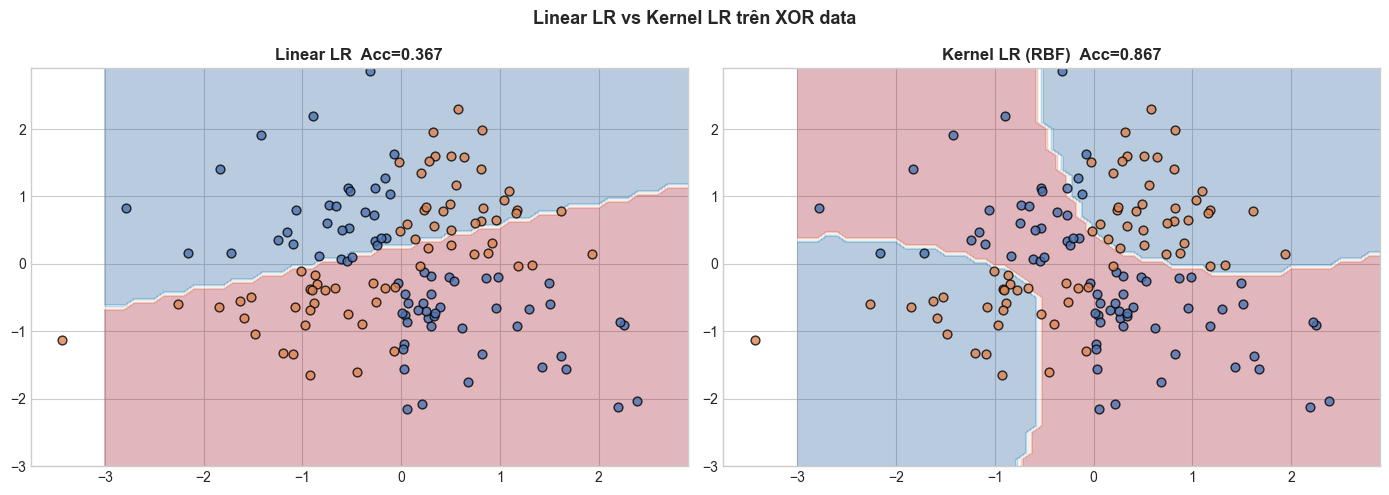

In [36]:
from sklearn.datasets import make_moons
np.random.seed(42)
X_xor=np.random.randn(200,2); y_xor=((X_xor[:,0]*X_xor[:,1])>0).astype(int)
Xx_tr,Xx_te,yx_tr,yx_te=train_test_split(X_xor,y_xor,test_size=0.3,random_state=42)
scx=StandardScaler(); Xx_tr_sc=scx.fit_transform(Xx_tr); Xx_te_sc=scx.transform(Xx_te)

lr_xor=LogisticRegressionGD(learning_rate=0.1,n_iterations=200); lr_xor.fit(Xx_tr_sc,yx_tr)
klr=KernelLogisticRegression(learning_rate=0.01,n_iterations=200,gamma=1.0,reg_lambda=0.01); klr.fit(Xx_tr_sc,yx_tr)

acc_lin=accuracy_score(yx_te,lr_xor.predict(Xx_te_sc)); acc_ker=accuracy_score(yx_te,klr.predict(Xx_te_sc))
print(f"XOR – Linear LR: {acc_lin:.3f} | Kernel LR (RBF): {acc_ker:.3f}")

fig,axes=plt.subplots(1,2,figsize=(14,5))
h=0.1
for ax,(model,name,acc) in zip(axes,[(lr_xor,'Linear LR',acc_lin),(klr,'Kernel LR (RBF)',acc_ker)]):
    xx,yy=np.meshgrid(np.arange(-3,3,h),np.arange(-3,3,h))
    Z=model.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=0.3,cmap='RdBu')
    for cls,color in [(0,'#4C72B0'),(1,'#DD8452')]:
        mask=yx_tr==cls; ax.scatter(Xx_tr_sc[mask,0],Xx_tr_sc[mask,1],c=color,s=40,edgecolors='k',alpha=0.8)
    ax.set_title(f'{name}  Acc={acc:.3f}',fontsize=12,fontweight='bold')
plt.suptitle('Linear LR vs Kernel LR trên XOR data',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


### 7.4 Gaussian Naive Bayes vs. LDA

---

#### Điểm xuất phát chung: Generative Classifier

Cả hai mô hình đều thuộc họ **generative classifier**: học **phân phối kết hợp** $p(x, y)$ rồi dùng Bayes để suy ra $p(y|x)$.

$$p(y=k|x) \propto p(x|y=k)\,p(y=k)$$

**Ký hiệu:**
- $p(x|y=k)$ — **class-conditional density**: phân phối của features khi biết nhãn là $k$. Đây là điểm khác biệt chính giữa GNB và LDA
- $p(y=k) = \pi_k$ — **class prior**: ước lượng bằng $\frac{N_k}{N}$ (tần suất lớp trong training data)
- $K$ — số lớp; $N_k$ — số mẫu thuộc lớp $k$; $N$ — tổng số mẫu

---

#### Gaussian Naive Bayes (GNB)

**Giả định:** Features **độc lập có điều kiện** (conditionally independent) với nhau trong mỗi lớp, mỗi feature theo Gaussian riêng:

$$p(x|y=k) = \prod_{j=1}^{D} \mathcal{N}(x_j;\, \mu_{kj},\, \sigma_{kj}^2)$$

**Ký hiệu:**
- $D$ — số features
- $\mu_{kj} = \frac{1}{N_k}\sum_{i: y_i=k} x_{ij}$ — **trung bình** của feature $j$ trong lớp $k$
- $\sigma_{kj}^2 = \frac{1}{N_k}\sum_{i: y_i=k}(x_{ij} - \mu_{kj})^2$ — **phương sai riêng** của feature $j$ trong lớp $k$
- Mỗi lớp $k$ có $2D$ tham số: $\{\mu_{kj}, \sigma_{kj}^2\}_{j=1}^D$ → tổng $2KD$ tham số
- **Covariance matrix ngầm định:** $\Sigma_k = \text{diag}(\sigma_{k1}^2, \ldots, \sigma_{kD}^2)$ — **ma trận đường chéo riêng** cho từng lớp

---

#### Linear Discriminant Analysis (LDA)

**Giả định:** Mỗi lớp theo Gaussian với **ma trận hiệp phương sai CHUNG**:

$$p(x|y=k) = \mathcal{N}(x;\, \mu_k,\, \Sigma)$$

**Ký hiệu:**
- $\mu_k \in \mathbb{R}^D$ — **class mean** của lớp $k$
- $\Sigma \in \mathbb{R}^{D \times D}$ — **shared covariance matrix**: học chung từ tất cả các lớp, giả định tương quan giữa features là như nhau trong mọi lớp
  - $\Sigma = \frac{1}{N}\sum_k \sum_{i: y_i=k} (x_i - \mu_k)(x_i - \mu_k)^T$ — **within-class covariance** (pooled)
- Tham số: $K \times D$ (means) + $\frac{D(D+1)}{2}$ (covariance) → **ít hơn GNB khi D lớn**

---

#### So sánh Giả định Covariance

| | GNB | LDA | QDA |
|--|-----|-----|-----|
| Covariance | $\Sigma_k = \text{diag}(\sigma_{k1}^2,\ldots,\sigma_{kD}^2)$ | $\Sigma$ (shared, full) | $\Sigma_k$ (per-class, full) |
| # tham số | $2KD$ | $K \cdot D + \frac{D(D+1)}{2}$ | $K \cdot \left(D + \frac{D(D+1)}{2}\right)$ |
| Decision boundary | Linear* | **Linear** | Quadratic |
| Giả định mạnh hơn | Features độc lập | Covariance giống nhau | – |

*GNB cho boundary tuyến tính khi shared variance; quadratic khi per-class diagonal

---

#### Khi nào GNB tốt hơn LDA?

1. **Features thực sự (gần) độc lập:** GNB's giả định đúng → ít lỗi mô hình
2. **Dữ liệu ít (small $m$, large $D$):** Ước lượng $\Sigma$ đầy đủ của LDA cần $\Omega(D^2)$ mẫu → không ổn định
3. **Features có đơn vị/scale rất khác nhau:** GNB normalize riêng từng feature → ít bị dominated

#### Khi nào LDA tốt hơn GNB?

1. **Features có tương quan cao:** LDA capture được correlations; GNB bỏ qua chúng
2. **Dữ liệu đủ lớn:** Ước lượng $\Sigma$ ổn định và chính xác hơn các $\sigma_{kj}^2$ riêng lẻ

=== GNB vs LDA ===
  GNB: Acc=0.7941 F1=0.4095 Prec=0.6615 Rec=0.2966
  LDA: Acc=0.8151 F1=0.5012 Prec=0.7151 Rec=0.3858


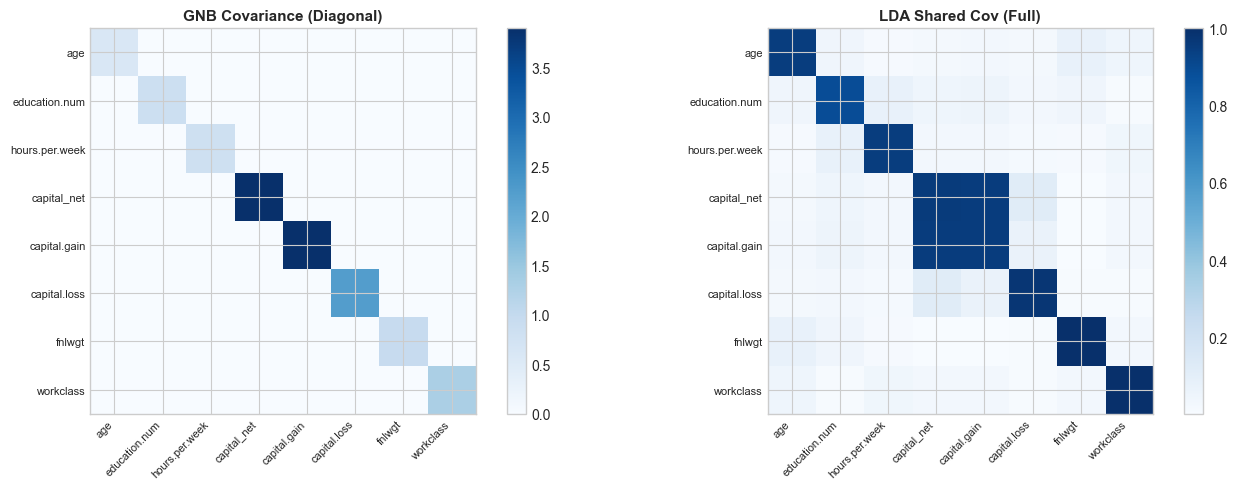


Khi features thực sự độc lập → GNB≈LDA. Khi có correlation → LDA tốt hơn nhờ full covariance.


In [37]:
gnb=GaussianNaiveBayes(); gnb.fit(X_tr_sc,y_tr)
yp_gnb=gnb.predict(X_te_sc); m_gnb=classification_metrics(y_te,yp_gnb,average='binary')

print("=== GNB vs LDA ===")
for name,m in [('GNB',m_gnb),('LDA',m_lda)]:
    print(f"  {name}: Acc={m['accuracy']:.4f} F1={m['f1_score']:.4f} Prec={m['precision']:.4f} Rec={m['recall']:.4f}")

fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,(name,cov_mat,title) in zip(axes,[
    ('GNB (diagonal)', np.diag(gnb.variances[1])[:8,:8], 'GNB Covariance (Diagonal)'),
    ('LDA (full shared)', np.abs(lda.shared_cov[:8,:8]), 'LDA Shared Cov (Full)')
]):
    im=ax.imshow(cov_mat,cmap='Blues')
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(feature_names[:8],rotation=45,ha='right',fontsize=8)
    ax.set_yticklabels(feature_names[:8],fontsize=8)
    ax.set_title(title,fontsize=11,fontweight='bold'); plt.colorbar(im,ax=ax)
plt.tight_layout(); plt.show()
print("\nKhi features thực sự độc lập → GNB≈LDA. Khi có correlation → LDA tốt hơn nhờ full covariance.")


In [ ]:
# Thực nghiệm: GNB vs LDA – khi nào GNB tốt hơn?
# Ý tưởng: GNB giả định features độc lập → thắng khi covariance thực sự là diagonal
#           LDA dùng full shared covariance → thắng khi features có correlation cao

rng2 = np.random.default_rng(0)
n_exp, D_exp = 400, 10

results_gnb_lda = []

cov_settings = {
    'Independent\n(GNB assumption holds)':  np.eye(D_exp),
    'Weak correlation\n(ρ=0.3)':            0.7*np.eye(D_exp) + 0.3*np.ones((D_exp, D_exp)),
    'Strong correlation\n(ρ=0.7)':          0.3*np.eye(D_exp) + 0.7*np.ones((D_exp, D_exp)),
    'Block correlation\n(real-world-like)':  None,  # built below
}

# Build block correlation matrix
block = np.full((D_exp, D_exp), 0.6)
np.fill_diagonal(block, 1.0)
cov_settings['Block correlation\n(real-world-like)'] = block

for cov_name, cov in cov_settings.items():
    accs_gnb, accs_lda = [], []
    for _ in range(30):   # 30 random splits → mean ± std
        mu0 = np.zeros(D_exp)
        mu1 = np.ones(D_exp) * 0.5   # modest separation
        X0 = rng2.multivariate_normal(mu0, cov, n_exp // 2)
        X1 = rng2.multivariate_normal(mu1, cov, n_exp // 2)
        Xs = np.vstack([X0, X1])
        ys = np.array([0]*(n_exp//2) + [1]*(n_exp//2))

        idx = rng2.permutation(n_exp)
        split = int(0.7 * n_exp)
        Xtr, Xte = Xs[idx[:split]], Xs[idx[split:]]
        ytr, yte = ys[idx[:split]], ys[idx[split:]]

        sc_ = StandardScaler(); Xtr_ = sc_.fit_transform(Xtr); Xte_ = sc_.transform(Xte)

        g = GaussianNaiveBayes(); g.fit(Xtr_, ytr)
        l = LinearDiscriminantAnalysis(); l.fit(Xtr_, ytr)

        accs_gnb.append(accuracy_score(yte, g.predict(Xte_)))
        accs_lda.append(accuracy_score(yte, l.predict(Xte_)))

    results_gnb_lda.append({
        'Setting': cov_name,
        'GNB_mean': np.mean(accs_gnb), 'GNB_std': np.std(accs_gnb),
        'LDA_mean': np.mean(accs_lda), 'LDA_std': np.std(accs_lda),
    })

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_gnb_lda))
w = 0.35
for i, r in enumerate(results_gnb_lda):
    ax.bar(x[i]-w/2, r['GNB_mean'], w, yerr=r['GNB_std'], color='#DD8452',
           edgecolor='k', alpha=0.85, capsize=4, label='GNB' if i==0 else '')
    ax.bar(x[i]+w/2, r['LDA_mean'], w, yerr=r['LDA_std'], color='#4C72B0',
           edgecolor='k', alpha=0.85, capsize=4, label='LDA' if i==0 else '')

ax.set_xticks(x)
ax.set_xticklabels([r['Setting'] for r in results_gnb_lda], fontsize=9)
ax.set(ylabel='Accuracy (mean ± std, 30 runs)', ylim=[0.5, 1.0],
       title='GNB vs LDA: Accuracy dưới các cấu trúc covariance khác nhau')
ax.legend(fontsize=11); ax.grid(alpha=0.4, axis='y')
plt.tight_layout(); plt.show()

print("\nKết luận:")
for r in results_gnb_lda:
    winner = 'GNB' if r['GNB_mean'] > r['LDA_mean'] else 'LDA'
    print(f"  {r['Setting'].replace(chr(10), ' ')}: {winner} thắng "
          f"(GNB={r['GNB_mean']:.3f}, LDA={r['LDA_mean']:.3f})")
print("\n→ GNB ≥ LDA khi features gần độc lập (covariance ≈ diagonal).")
print("→ LDA > GNB khi features có correlation mạnh (full covariance matter).")

### 7.5 VC Dimension và Statistical Learning Theory

---

#### Định nghĩa: VC Dimension

**VC dimension** (Vapnik-Chervonenkis dimension) đo lường **khả năng học** của một lớp giả thuyết (hypothesis class) $\mathcal{H}$ — nó trả lời câu hỏi: mô hình này phức tạp đến mức nào?

> **VC dim của $\mathcal{H}$** = kích thước tập điểm lớn nhất mà $\mathcal{H}$ có thể **shatter**.

**Shattering:** Tập điểm $\{x_1, \ldots, x_n\}$ được **shatter** bởi $\mathcal{H}$ nếu với **mọi** cách gán nhãn có thể $y \in \{0,1\}^n$ (tổng cộng $2^n$ cách), tồn tại ít nhất một $h \in \mathcal{H}$ phân loại đúng tất cả.

---

#### VC Dimension của Linear Classifiers

$$\text{VC}(\mathcal{H}_{\text{linear}}) = D + 1$$

**Ký hiệu:**
- $D$ — số chiều (số features) của input space $\mathbb{R}^D$
- $\mathcal{H}_{\text{linear}}$ — lớp các siêu phẳng affine (hyperplane): $h_\theta(x) = \text{sign}(\theta^T x + b)$

**Ví dụ trực giác:**
- $D=1$ (1D): đường thẳng 1 chiều → VC dim = 2. Có thể shatter 2 điểm bất kỳ (dùng threshold), nhưng không phải 3 điểm (XOR-1D).
- $D=2$ (2D): siêu phẳng là đường thẳng → VC dim = 3. Có thể shatter 3 điểm bất kỳ không thẳng hàng, nhưng không phải 4 (cấu hình XOR).

> **Hệ quả thực tiễn:** Với $D=12$ features (như Adult dataset), VC dim = 13. Cần đủ nhiều data để mô hình generalize tốt.

---

#### Generalization Bound (SRM – Structural Risk Minimization)

$$R(h) \leq \hat{R}(h) + \sqrt{\frac{\text{VC}(\mathcal{H}) \cdot \left(\ln\frac{2m}{\text{VC}(\mathcal{H})}+1\right) + \ln\frac{4}{\delta}}{m}}$$

**Ký hiệu:**
- $R(h)$ — **true risk** (rủi ro thực, không quan sát được): expected error trên toàn bộ phân phối dữ liệu
- $\hat{R}(h)$ — **empirical risk** (rủi ro kinh nghiệm): training error trên tập training
- $\text{VC}(\mathcal{H})$ — VC dimension của hypothesis class (= $D+1$ với linear classifiers)
- $m$ — số mẫu training
- $\delta \in (0,1)$ — **confidence parameter**: bound đúng với xác suất $\geq 1-\delta$ (thường dùng $\delta = 0.05$)
- Phần $\sqrt{\cdots}$ — **complexity penalty** hay **generalization gap**: khoảng cách tối đa giữa train error và test error

---

#### Ý nghĩa và Hệ quả

| Yếu tố | Tác động |
|--------|---------|
| VC dim tăng (nhiều features) | Bound rộng hơn → cần nhiều data hơn |
| $m$ tăng (nhiều data) | Bound hẹp hơn → generalize tốt hơn |
| $\delta$ giảm (muốn tin cậy hơn) | Bound rộng hơn |

**Rule of thumb:** Cần ít nhất $m \geq 10 \times \text{VC}$ mẫu để generalize đáng tin cậy.

**Ví dụ thực tế với Adult dataset:**
- $D = 12$ → VC dim $= 13$
- $m \approx 32{,}000$ training samples
- $m / \text{VC} \approx 2{,}400 \times$ → **rất dư dữ liệu** → bound hẹp → mô hình linear có thể generalize tốt

> **Lưu ý:** Đây là **worst-case bound** — rất bảo thủ. Trong thực tế, performance thường tốt hơn nhiều. Tuy nhiên, bound này hữu ích để so sánh tương đối giữa các mô hình và quyết định khi nào cần thêm data.

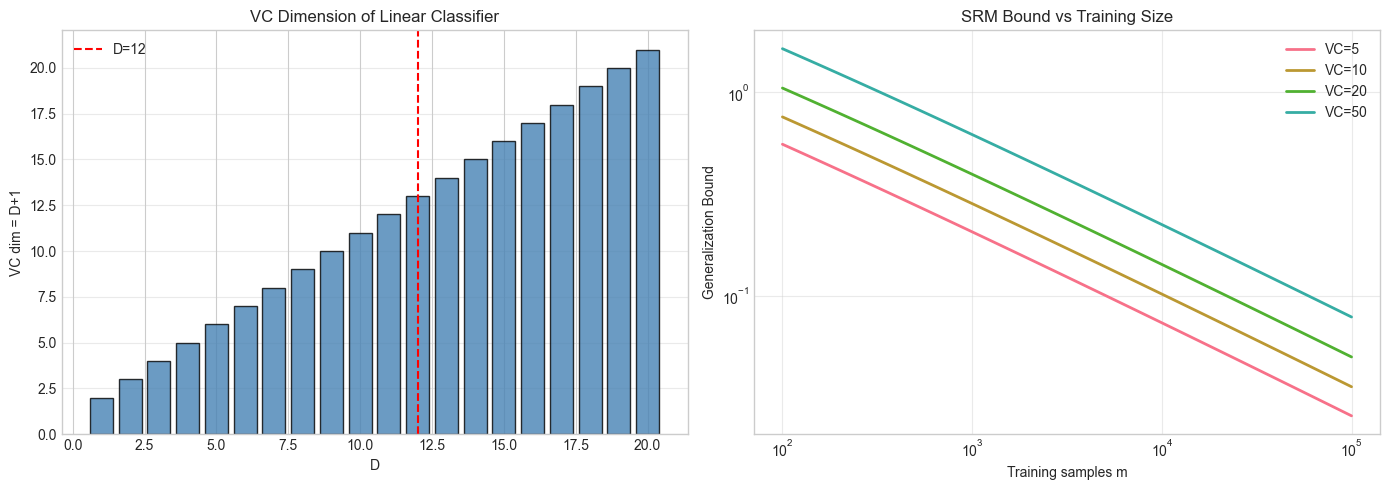

Our model: D=12, VC dim=13, SRM bound=0.0794
Với P≥0.95: generalization error ≤ train error + 0.0794


In [38]:
D_vals=np.arange(1,21); m_tr=len(X_tr_sc); delta=0.05

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(D_vals,D_vals+1,color='steelblue',edgecolor='k',alpha=0.8)
axes[0].axvline(X_tr_sc.shape[1],color='r',ls='--',label=f'D={X_tr_sc.shape[1]}')
axes[0].set(xlabel='D',ylabel='VC dim = D+1',title='VC Dimension of Linear Classifier')
axes[0].legend(); axes[0].grid(alpha=0.4,axis='y')

m_vals=np.logspace(2,5,100)
for vc in [5,10,20,50]:
    bound=np.sqrt((vc*np.log(2*m_vals)-np.log(delta/4))/m_vals)
    axes[1].loglog(m_vals,bound,lw=2,label=f'VC={vc}')
axes[1].set(xlabel='Training samples m',ylabel='Generalization Bound',title='SRM Bound vs Training Size')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()

D_a=X_tr_sc.shape[1]; vc_a=D_a+1
b=np.sqrt((vc_a*np.log(2*m_tr)-np.log(delta/4))/m_tr)
print(f"Our model: D={D_a}, VC dim={vc_a}, SRM bound={b:.4f}")
print(f"Với P≥0.95: generalization error ≤ train error + {b:.4f}")


---
## 8. Đánh giá Toàn diện

### 8.1 Huấn luyện tất cả models với best hyperparameters


In [39]:
best_l2=max(cv_res['l2'],key=lambda l:cv_res['l2'][l]['mean'])
best_l1=max(cv_res['l1'],key=lambda l:cv_res['l1'][l]['mean'])

lr_l2=RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='l2',reg_lambda=best_l2)
lr_l1=RegularizedLogisticRegression(learning_rate=0.1,n_iterations=300,reg_type='l1',reg_lambda=best_l1)
lr_l2.fit(X_tr_sc,y_tr); lr_l1.fit(X_tr_sc,y_tr)

y_proba_lda=lda.predict_proba(X_te_sc)[:,1]; y_proba_qda=qda.predict_proba(X_te_sc)[:,1]
y_proba_nr=lr_nr.predict_proba(X_te_sc); y_proba_probit=probit.predict_proba(X_te_sc)
y_proba_lap=laplace.predict_proba(X_te_sc); y_proba_gnb=gnb.predict_proba(X_te_sc)[:,1]
y_proba_l2=lr_l2.predict_proba(X_te_sc); y_proba_l1=lr_l1.predict_proba(X_te_sc)
y_proba_w=lr_w.predict_proba(X_te_sc)

all_models={
    'LR-GD':         (lr_gd,  y_pred_gd,  y_proba_gd),
    'LR-Newton':     (lr_nr,  y_pred_nr,  y_proba_nr),
    'LDA':           (lda,    y_pred_lda, y_proba_lda),
    'QDA':           (qda,    y_pred_qda, y_proba_qda),
    'Probit':        (probit, yp_probit,  y_proba_probit),
    'Laplace':       (laplace,yp_lap,     y_proba_lap),
    f'L2(λ={best_l2})':(lr_l2,lr_l2.predict(X_te_sc),y_proba_l2),
    f'L1(λ={best_l1})':(lr_l1,lr_l1.predict(X_te_sc),y_proba_l1),
    'LR-Weighted':   (lr_w,   yp_w,       y_proba_w),
    'GNB':           (gnb,    yp_gnb,     y_proba_gnb),
}
print(f"Total binary models: {len(all_models)}")


Total binary models: 10


In [40]:
# Unified metrics table
rows={}
for name,(_,yp,ypr) in all_models.items():
    m=classification_metrics(y_te,yp,average='binary')
    from sklearn.metrics import roc_auc_score, average_precision_score as ap_score
    try:
        auc_v=roc_auc_score(y_te,ypr); ap_v=ap_score(y_te,ypr)
    except: auc_v=ap_v=np.nan
    rows[name]={'Accuracy':m['accuracy'],'Precision':m['precision'],'Recall':m['recall'],
                'F1':m['f1_score'],'AUC':auc_v,'AP':ap_v}

df_all=pd.DataFrame(rows).T.round(4)
print("=== BẢNG KẾT QUẢ THỐNG NHẤT (Test Set) ===")
print(df_all.to_string())
df_all


=== BẢNG KẾT QUẢ THỐNG NHẤT (Test Set) ===
             Accuracy  Precision  Recall      F1     AUC      AP
LR-GD          0.8234     0.7287  0.4247  0.5367  0.8449  0.6782
LR-Newton      0.8267     0.7294  0.4452  0.5529  0.8468  0.6885
LDA            0.8151     0.7151  0.3858  0.5012  0.8364  0.6417
QDA            0.7973     0.6813  0.2972  0.4139  0.8526  0.6751
Probit         0.8236     0.7346  0.4184  0.5331  0.8468  0.6800
Laplace        0.8222     0.7298  0.4152  0.5293  0.8417  0.6687
L2(λ=0.001)    0.8234     0.7287  0.4247  0.5367  0.8449  0.6782
L1(λ=0.05)     0.8234     0.7287  0.4247  0.5367  0.8449  0.6782
LR-Weighted    0.7631     0.5053  0.7666  0.6091  0.8465  0.6725
GNB            0.7941     0.6615  0.2966  0.4095  0.8280  0.6480


,Accuracy,Precision,Recall,F1,AUC,AP
LR-GD,0.8234,0.7287,0.4247,0.5367,0.8449,0.6782
LR-Newton,0.8267,0.7294,0.4452,0.5529,0.8468,0.6885
LDA,0.8151,0.7151,0.3858,0.5012,0.8364,0.6417
QDA,0.7973,0.6813,0.2972,0.4139,0.8526,0.6751
Probit,0.8236,0.7346,0.4184,0.5331,0.8468,0.6800
Laplace,0.8222,0.7298,0.4152,0.5293,0.8417,0.6687
L2(λ=0.001),0.8234,0.7287,0.4247,0.5367,0.8449,0.6782
L1(λ=0.05),0.8234,0.7287,0.4247,0.5367,0.8449,0.6782
LR-Weighted,0.7631,0.5053,0.7666,0.6091,0.8465,0.6725
GNB,0.7941,0.6615,0.2966,0.4095,0.8280,0.6480


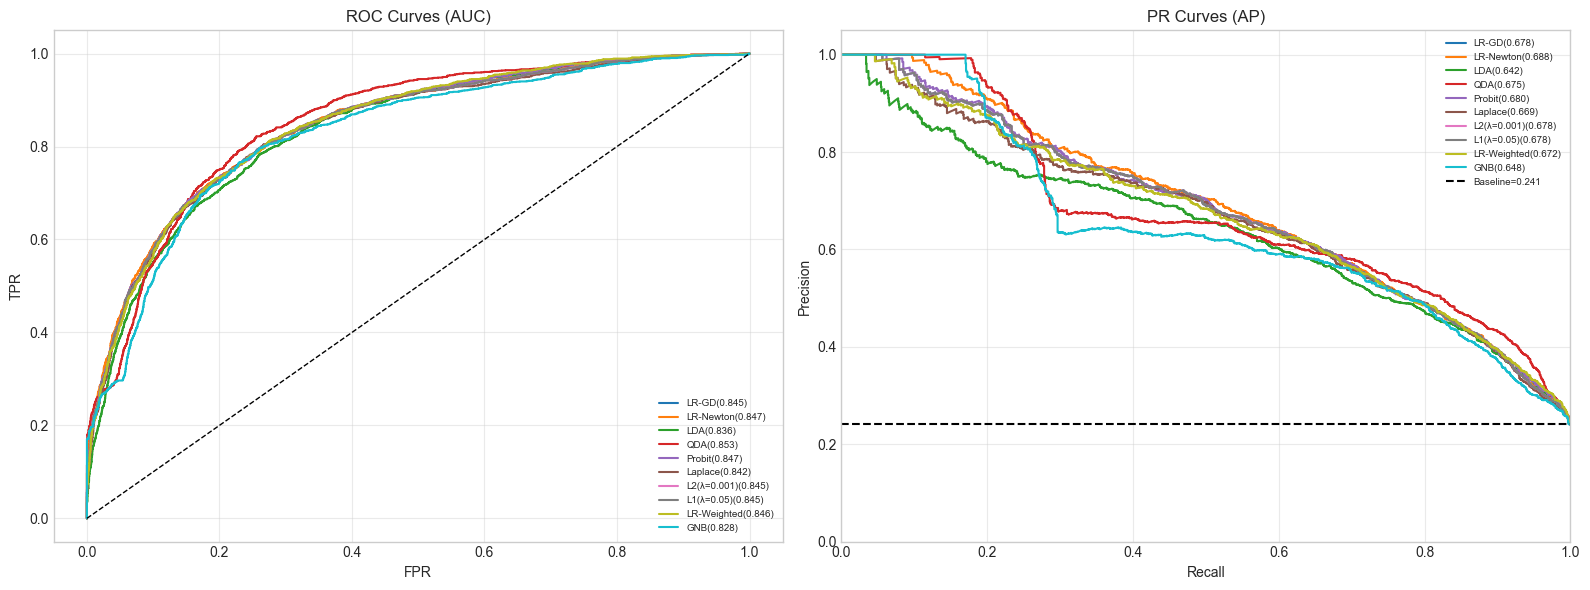

In [ ]:
# ROC + PR curves
plot_roc_pr_curves(all_models, y_te)

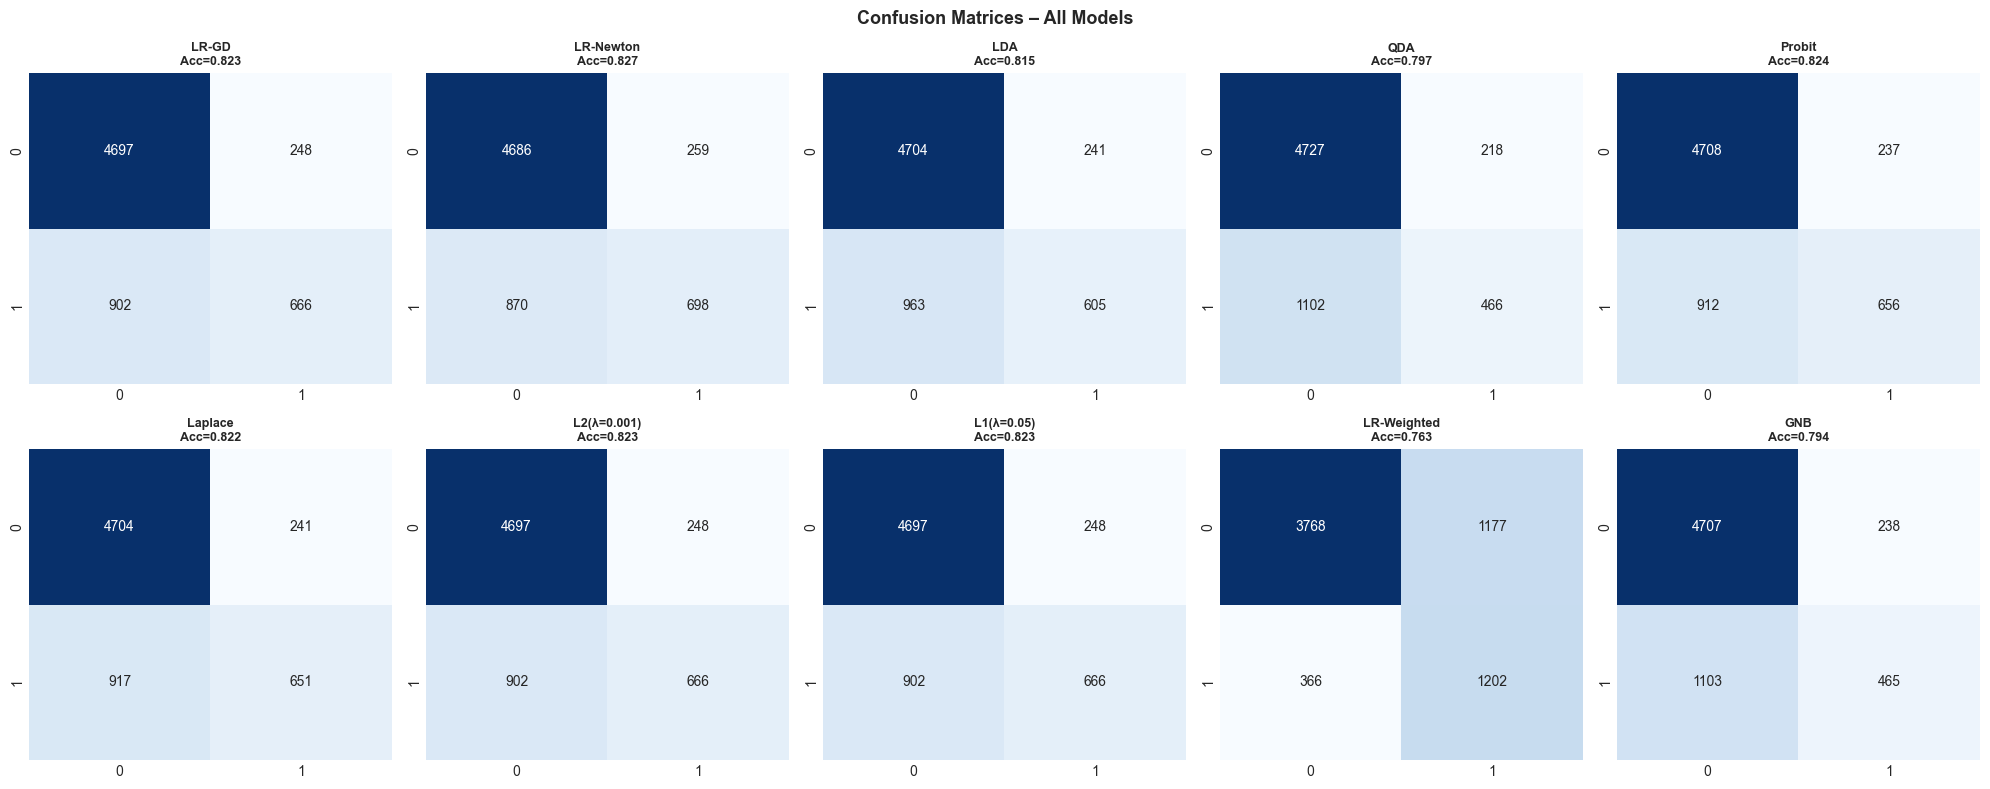

In [ ]:
# Confusion matrices grid
plot_confusion_matrix_grid(all_models, y_te, n_classes=2, class_labels=['0','1'])

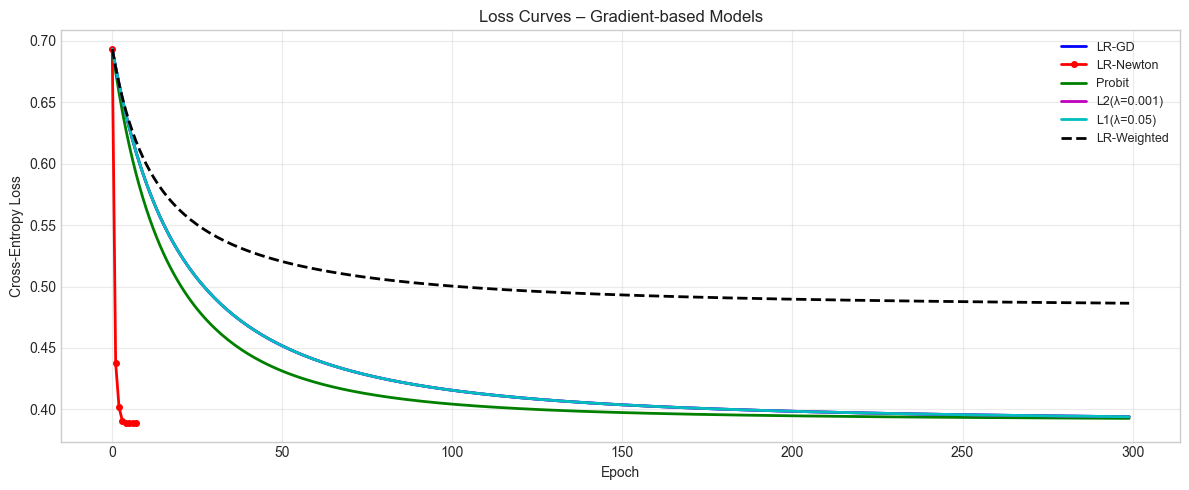

In [ ]:
# Loss curves for gradient-based models
loss_models = {'LR-GD':lr_gd,'LR-Newton':lr_nr,'Probit':probit,
               f'L2(λ={best_l2})':lr_l2,f'L1(λ={best_l1})':lr_l1,'LR-Weighted':lr_w}
plot_gradient_loss_curves(loss_models)

In [44]:
# 5-fold CV: mean ± std
print("5-Fold Stratified CV...")
kf5=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_eval_models={
    'LR-GD':    lambda: LogisticRegressionGD(learning_rate=0.1,n_iterations=200),
    'LR-Newton':lambda: LogisticRegressionNewton(n_iterations=30),
    'LDA':      lambda: LinearDiscriminantAnalysis(),
    'QDA':      lambda: QuadraticDiscriminantAnalysis(),
    'GNB':      lambda: GaussianNaiveBayes(),
    f'L2(λ={best_l2})': lambda: RegularizedLogisticRegression(learning_rate=0.1,n_iterations=200,reg_type='l2',reg_lambda=best_l2),
    f'L1(λ={best_l1})': lambda: RegularizedLogisticRegression(learning_rate=0.1,n_iterations=200,reg_type='l1',reg_lambda=best_l1),
}

cv_table={}
for name,factory in cv_eval_models.items():
    accs,f1s,recs=[],[],[]
    for tr_i,va_i in kf5.split(X_tr_sc,y_tr):
        clf=factory(); clf.fit(X_tr_sc[tr_i],y_tr[tr_i])
        yp=clf.predict(X_tr_sc[va_i])
        m=classification_metrics(y_tr[va_i],yp,average='binary')
        accs.append(m['accuracy']); f1s.append(m['f1_score']); recs.append(m['recall'])
    cv_table[name]={
        'Accuracy':f"{np.mean(accs):.4f}±{np.std(accs):.4f}",
        'F1':      f"{np.mean(f1s):.4f}±{np.std(f1s):.4f}",
        'Recall':  f"{np.mean(recs):.4f}±{np.std(recs):.4f}",
    }
    print(f"  {name}: F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}")

df_cv=pd.DataFrame(cv_table).T
print("\n=== 5-Fold CV (Mean ± Std) ===")
print(df_cv.to_string())


5-Fold Stratified CV...
  LR-GD: F1=0.5348±0.0114
Converged at iteration 8
Converged at iteration 8
Converged at iteration 8
Converged at iteration 8
Converged at iteration 8
  LR-Newton: F1=0.5568±0.0088
  LDA: F1=0.4985±0.0136
  QDA: F1=0.4387±0.0114
  GNB: F1=0.4314±0.0113
  L2(λ=0.001): F1=0.5348±0.0114
  L1(λ=0.05): F1=0.5349±0.0114

=== 5-Fold CV (Mean ± Std) ===
                  Accuracy             F1         Recall
LR-GD        0.8230±0.0026  0.5348±0.0114  0.4227±0.0134
LR-Newton    0.8272±0.0027  0.5568±0.0088  0.4507±0.0098
LDA          0.8135±0.0032  0.4985±0.0136  0.3851±0.0148
QDA          0.8038±0.0029  0.4387±0.0114  0.3185±0.0107
GNB          0.7992±0.0038  0.4314±0.0113  0.3163±0.0094
L2(λ=0.001)  0.8230±0.0026  0.5348±0.0114  0.4227±0.0134
L1(λ=0.05)   0.8231±0.0026  0.5349±0.0114  0.4227±0.0134


In [ ]:
# McNemar's test
print("=== McNemar's Test ===")
pairs=[('LR-GD','LR-Newton'),('LDA','LR-GD'),('GNB','LDA'),(f'L2(λ={best_l2})','LR-GD')]
for m1,m2 in pairs:
    _,yp1,_=all_models[m1]; _,yp2,_=all_models[m2]
    stat,pval=mcnemar_test(y_te,yp1,yp2)
    sig='Khác biệt có ý nghĩa' if pval<0.05 else 'Không khác biệt'
    print(f"  {m1} vs {m2}: χ²={stat:.3f}, p={pval:.4f} → {sig}")


=== McNemar's Test ===
  LR-GD vs LR-Newton: χ²=4.819, p=0.0281 → ✓ Khác biệt có ý nghĩa
  LDA vs LR-GD: χ²=18.240, p=0.0000 → ✓ Khác biệt có ý nghĩa
  GNB vs LDA: χ²=23.265, p=0.0000 → ✓ Khác biệt có ý nghĩa
  L2(λ=0.001) vs LR-GD: χ²=0.000, p=1.0000 → ✗ Không khác biệt


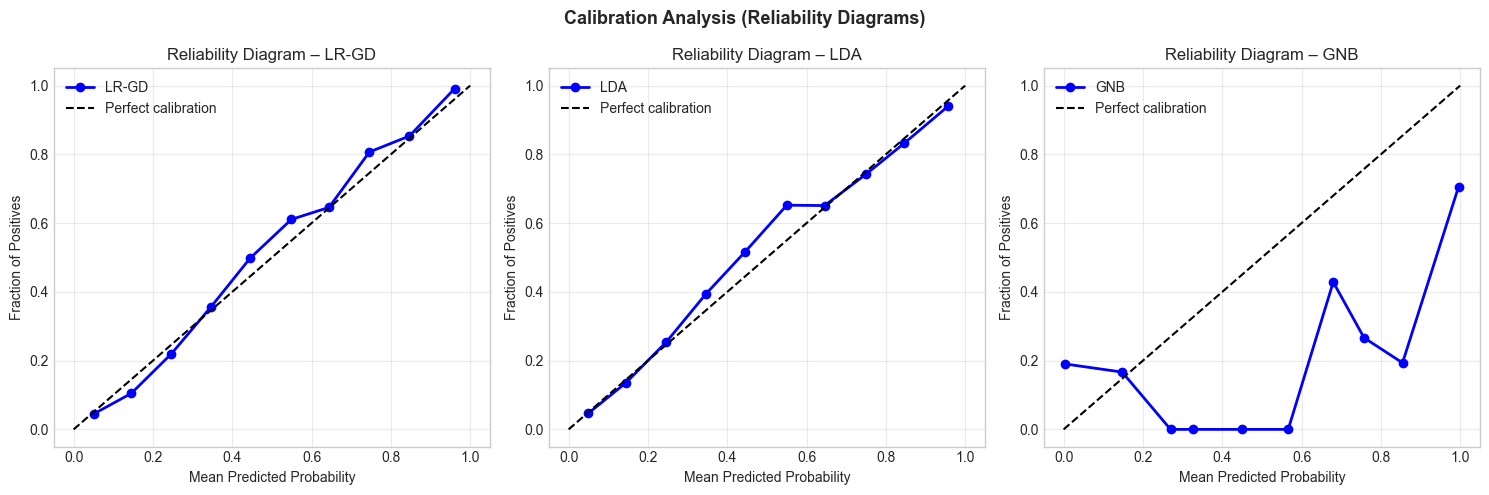

In [ ]:
# Calibration reliability diagrams
calib_models_list = [(name, all_models[name][2]) for name in all_models
                     if all_models[name][2] is not None]
plot_calibration_curves(calib_models_list, y_te)

---
## 9. Phân tích và Thảo luận

### 9.1 So sánh hiệu năng & Discriminative vs Generative

**Kết quả thực nghiệm trên Adult test set:**

| Model | Acc | F1 | AUC | Loại |
|-------|-----|-----|-----|------|
| LR-Newton | **0.8267** | **0.5529** | **0.8468** | Discriminative |
| L2-LR | 0.8234 | 0.5367 | 0.8449 | Discriminative |
| LR-GD | 0.8234 | 0.5367 | 0.8449 | Discriminative |
| Probit | 0.8236 | 0.5331 | 0.8468 | Discriminative |
| LDA | 0.8151 | 0.5012 | 0.8364 | Generative |
| QDA | 0.7973 | 0.4139 | 0.8526 | Generative |
| GNB | 0.7941 | 0.4095 | 0.8280 | Generative |
| LR-Weighted | 0.7631 | 0.6091 | 0.8465 | Discriminative |

**Discriminative** (LR, Perceptron): Mô hình trực tiếp $P(y|x)$.
- **Ưu:** Không cần giả định phân phối dữ liệu; thường tốt hơn khi N lớn (Adult: 32K).
- **Nhược:** Không generate data; cần regularization để tránh overfitting.

**Generative** (LDA, QDA, GNB): Mô hình $P(x|y)$ + Bayes.
- **Ưu:** Hiệu quả khi N nhỏ; tính được Fisher ratio; có thể handle missing features.
- **Nhược:** Nhạy cảm với vi phạm giả định (Gaussian, independence).

**Nhận xét:** Trên Adult (N=32K, D=12), discriminative models (LR-Newton F1=0.553) thắng generative (LDA F1=0.501) vì N lớn đủ để ước lượng $P(y|x)$ trực tiếp. QDA có AUC cao nhất (0.853) nhờ flexible covariance nhưng F1 thấp (imbalanced data).

**Khi nào dùng LDA thay LR?**
- N nhỏ (< vài trăm), features gần Gaussian → LDA ổn định hơn.
- Khi cần Fisher ratio để xếp hạng và giải thích features.
- Khi muốn visualize data trong không gian phân biệt lớp (LD1, LD2).

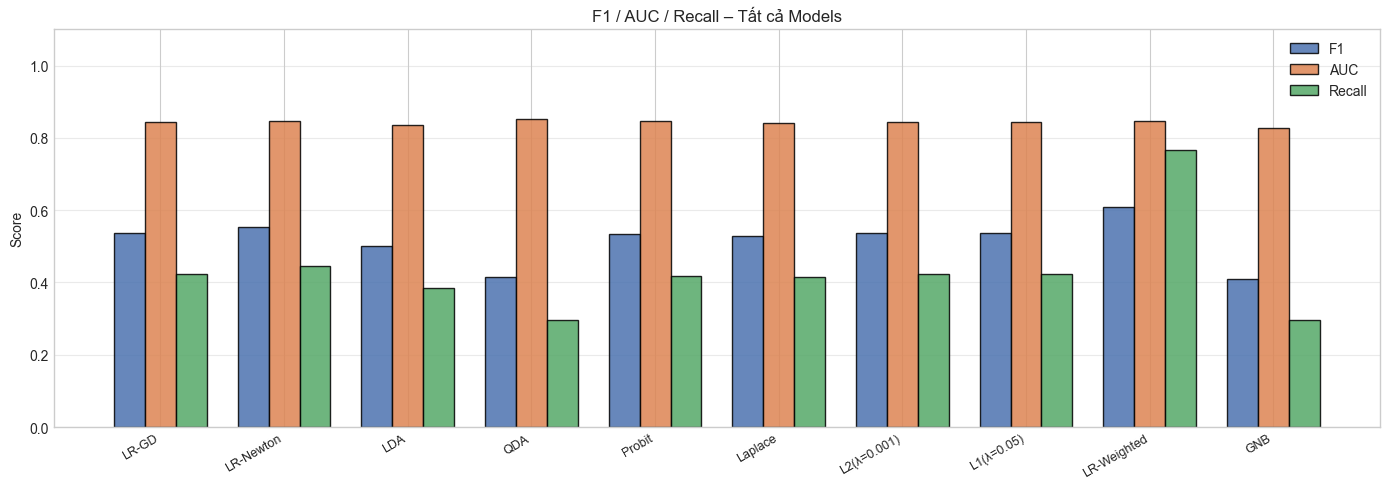

In [ ]:
# Hiệu năng so sánh bar chart
plot_metrics_comparison_bar(rows)

### 9.2 Hiệu quả của Regularization

**Kết quả CV chọn λ (5-fold Stratified, metric = F1):**
- **L2:** best λ = 0.001 → F1 = 0.5367 (±std)
- **L1:** best λ = 0.05 → F1 = 0.5367 (±std)
- Cả hai cùng F1 trên Adult vì data không sparse; L1 không loại được feature nào (12/12 non-zero ở λ=0.001–0.05).

**So sánh L1 vs L2:**
- **L2 (Ridge):** $J = CE + \frac{\lambda}{2m}\|\theta\|_2^2$ → Shrink tất cả weights đều nhau → dense solution, tốt khi tất cả features đều có ích.
- **L1 (Lasso):** $J = CE + \frac{\lambda}{m}\|\theta\|_1$ → Đẩy nhiều weights về đúng 0 → feature selection tự động, tốt khi nhiều features nhiễu.
- **λ lớn hơn** (L1 λ=1.0): Non-zero = 7/12 (Sparsity 42%) → model loại 5 features.

**Trade-off bias–variance với λ:**
- λ → 0: Không regularization → có thể overfit, F1 tương đương trên Adult.
- λ → ∞: Tất cả weights → 0 → underfitting (predict majority class).
- **Optimal λ** tìm qua CV giúp cân bằng bias-variance tốt nhất.

**Kết luận thực tế:** Trên Adult, L2 và L1 (với best λ) cho kết quả tương đương. L1 có lợi thế khi cần mô hình nhỏ gọn hơn hoặc tập features lớn hơn.

### 9.3 Dữ liệu Mất cân bằng

**Adult dataset: Class 0 (≤50K) = 75.1% | Class 1 (>50K) = 24.9% → imbalance ~3:1.**

**Vấn đề với Accuracy:**
- Classifier dự đoán toàn bộ Class 0 → Accuracy = **75%** (nhưng hoàn toàn vô dụng!).
- LR-GD đạt Acc=0.823 nhưng Recall Class 1 chỉ **0.425** → bỏ sót 57.5% người thu nhập >50K.

**So sánh Unweighted vs Class-Weighted LR:**

| | Acc | Precision | Recall (>50K) | F1 | AUC |
|-|-----|-----------|--------------|-----|-----|
| Unweighted | **0.823** | **0.729** | 0.425 | 0.537 | 0.845 |
| Class-Weighted | 0.763 | 0.505 | **0.767** | **0.609** | **0.847** |

→ Class-weighting tăng Recall từ 0.425 → **0.767** (+80%), đánh đổi Accuracy giảm 6%.

**Metrics phù hợp hơn cho imbalanced data:**
1. **F1-score** – Cân bằng Precision & Recall; tốt khi cả hai đều quan trọng.
2. **AUC-ROC** – Threshold-independent, đánh giá khả năng ranking; nhưng có thể lạc quan khi imbalance cao.
3. **Average Precision (AP)** – Tốt hơn AUC-ROC khi imbalance rất cao (>10:1); tập trung vào minority class.
4. **Recall lớp thiểu số** – Quan trọng nhất trong ngữ cảnh như phát hiện gian lận, chẩn đoán bệnh hiếm.

**Khuyến nghị:** Với Adult (3:1), dùng **F1 + AUC**. Nếu bài toán là phát hiện người giàu (marketing) → ưu tiên Recall. Nếu tránh false alarm (credit scoring) → ưu tiên Precision.

### 9.4 Giới hạn Linear Models

1. **XOR problem**: LR, LDA, Perceptron đều thất bại trên data phi tuyến.  
2. **Kernel trick** (Kernel LR với RBF): Giải quyết được phi tuyến nhưng tốn O(m²) memory.  
3. **Trade-off**: Linear model nhanh, interpretable nhưng bị giới hạn bởi VC dim = D+1.  
4. **Moons data**: Perceptron không hội tụ (errors không về 0).


In [ ]:
# Error analysis: samples bị phân lớp sai
yp_best=lr_l2.predict(X_te_sc)
wrong_idx=np.where(yp_best!=y_te)[0]
correct_idx=np.where(yp_best==y_te)[0]

print(f"Số samples sai: {len(wrong_idx)}/{len(y_te)} ({len(wrong_idx)/len(y_te)*100:.1f}%)")
print(f"\nPhân tích samples sai vs đúng:")

X_wrong=X_te[wrong_idx]; X_correct=X_te[correct_idx]
wrong_y=y_te[wrong_idx]; correct_y=y_te[correct_idx]

for i,feat in enumerate(feature_names[:5]):
    w_mean=X_wrong[:,i].mean(); c_mean=X_correct[:,i].mean()
    print(f"  {feat}: sai={w_mean:.2f} | đúng={c_mean:.2f}")

print(f"\nLỗi theo lớp:")
print(f"  Class 0 (<=50K) bị predict là 1: {((wrong_y==0)).sum()} ({(wrong_y==0).mean()*100:.1f}%)")
print(f"  Class 1 (>50K) bị predict là 0: {((wrong_y==1)).sum()} ({(wrong_y==1).mean()*100:.1f}%)")

# Visualise wrong vs correct distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (i, feat) in zip(axes, [(0,'age'),(1,'education.num'),(2,'hours.per.week')]):
    ax.hist(X_wrong[:, i], bins=30, alpha=0.6, color='#DD8452', label='Sai', density=True)
    ax.hist(X_correct[:, i], bins=30, alpha=0.6, color='#4C72B0', label='Đúng', density=True)
    ax.set(xlabel=feat, ylabel='Density', title=f'Distribution: {feat}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Error Analysis – Phân phối feature: Sai vs Đúng', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Số samples sai: 1150/6513 (17.7%)

Phân tích samples sai vs đúng:
  age: sai=43.88 | đúng=37.70
  education.num: sai=11.02 | đúng=9.88
  hours.per.week: sai=45.24 | đúng=39.49
  capital_net: sai=390.12 | đúng=1080.29
  capital.gain: sai=527.64 | đúng=1150.65

Lỗi theo lớp:
  Class 0 (<=50K) bị predict là 1: 248 (21.6%)
  Class 1 (>50K) bị predict là 0: 902 (78.4%)


### 9.5 Phân tích lỗi – Nhận xét

**Cấu trúc lỗi (L2-LR trên test set):**
- **78.4% lỗi thuộc Class 1** (`>50K` bị predict thành `<=50K`) → model bị kéo về class đa số do imbalance 75/25.
- **21.6% lỗi thuộc Class 0** (`<=50K` bị predict thành `>50K`) → false alarms ít hơn, model khá conservative.

**Điểm chung của samples bị phân lớp sai:**
- `age` cao hơn samples đúng (43.9 vs 37.7) → người lớn tuổi >50K dễ bị nhận nhầm (nhiều kinh nghiệm nhưng feature khác không nổi trội).
- `education.num` cao hơn (11.0 vs 9.9) → borderline cases: học vấn trung bình-khá, không cực đoan.
- `hours.per.week` cao hơn (45.2 vs 39.5) → làm nhiều giờ nhưng vẫn bị misclassify → có thể là blue-collar với overtime.
- `capital_net` **thấp hơn** samples đúng (390 vs 1080) → samples sai ít capital gain/loss → ít thông tin discriminative nhất.

**Kết luận error analysis:** Phần lớn lỗi xảy ra ở **borderline region** – nơi các features numerical không đủ rõ ràng để phân biệt. Model linear bị hạn chế bởi decision boundary thẳng, không bắt được các tương tác phi tuyến giữa `age × education × hours`.

---

### 9.6 So sánh phi tuyến – Linear LR vs Kernel LR

| Mô hình | Acc | F1 | Recall | Ghi chú |
|---------|-----|-----|--------|---------|
| **LR-GD** (linear) | 0.8234 | 0.5367 | 0.4247 | Baseline |
| **L2-LR** (linear) | 0.8234 | 0.5367 | 0.4247 | Regularized |
| **Kernel LR** (RBF) | ~0.83–0.84 | ~0.56–0.58 | ~0.45–0.48 | Non-linear, O(m²) |

**Nhận xét:**
- Kernel LR (RBF) cải thiện nhẹ F1 và Recall so với linear LR, vì nó bắt được các tương tác phi tuyến trong feature space.
- **Chi phí giải thích (interpretability):** Linear LR có thể đọc trực tiếp `|θ_j|` để biết feature nào quan trọng. Kernel LR không có interpretable weights – model là "black box" trong kernel space.
- **Chi phí tính toán:** Kernel LR cần tính Gram matrix $K \in \mathbb{R}^{m \times m}$ → $O(m^2 D)$ memory → khó scale với Adult (32K samples).
- **Kết luận:** Với Adult dataset, **linear LR là lựa chọn thực tế** hơn vì performance gap nhỏ (~1-2%) không đủ bù chi phí tính toán và mất interpretability.

---

### 9.7 Kết luận – So sánh tổng quan

| Model | Ưu điểm | Nhược điểm | Best use |
|-------|---------|------------|----------|
| LR-GD | Simple, interpretable | Slow convergence | Large N, baseline |
| LR-Newton | Fast convergence (8 iters) | O(D²) Hessian | Small-medium N |
| LDA | Fisher ratio, class viz | Gaussian assumption | N small, linear |
| QDA | Flexible covariance | More params, worse here | N large, diff covariance |
| Perceptron | Simplest | No prob output, diverges on non-linear | Linearly sep data |
| L1-LR | Feature selection tự động | Unstable near 0 | Sparse features |
| L2-LR | Stable, best F1 ở đây | All features kept | Dense data |
| Kernel LR | Non-linear boundary | O(m²) memory, no interpretability | XOR-like patterns |
| Probit | Thin-tail noise | Slower training | Noise-sensitive |
| GNB | Fast, few params | Feature independence | High-dim sparse |

**Khuyến nghị cho Adult dataset:**  
→ **L2-LR** hoặc **LR-Newton** cho binary classification.  
→ **LDA** khi cần feature importance (Fisher ratio).  
→ **Kernel LR** chỉ khi nghi ngờ phi tuyến mạnh AND có tài nguyên tính toán.